# Small Area Estimation of Network Coverage at District Level in Zimbabwe
## Using Call Detail Records (CDR), Fay-Herriot, GLMM, and XGBoost Models

---
**Objectives:**
1. **Model Development** — Develop three competing models: Fay-Herriot EBLUP, GLMM (LMM on logit scale), and XGBoost
2. **Model Comparison** — Select the best model using AIC, BIC, RMSE, MAE, R², CV, and Pearson correlation
3. **Estimation** — Produce a district-level table of estimated proportions of 4G/5G network coverage with uncertainty measures

---


## 1. Importing Libraries

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import geopandas as gpd
import seaborn as sns
import xgboost as xgb
import scipy.stats as stats
import shap
import warnings

from statsmodels.tools.tools import add_constant
from statsmodels.regression.mixed_linear_model import MixedLM
from shapely.geometry import Point
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option('display.float_format', '{:.6f}'.format)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)

print("Libraries loaded successfully ✓")


Libraries loaded successfully ✓


## 2. Data Loading

In [15]:
# ── CDR Data ──────────────────────────────────────────────────────────────
cdr_df = pd.read_csv(r"C:/Users/peter/OneDrive/Documents/PROJECT_DATA BASES/synthetic_project data/Final_CDR_DATA.csv")

# ── Select only necessary columns ──────────────────────────────────────────
cdr_df = cdr_df[['homing_province','homing_region','homing_district',
                  'homing_clusters','homing_sitecode',
                  'homing_longitude','homing_latitude',
                  'device_type','gender','dob','age','part_month',
                  'call_type','network_type','call_duration',
                  'caller_msisdn','receiver_msisdn']]

# ── Age filter (plausible range) ────────────────────────────────────────────
cdr_df = cdr_df[(cdr_df['age'] >= 5) & (cdr_df['age'] <= 110)]

print(f"CDR records loaded:  {len(cdr_df):,}")
print(f"Columns:             {list(cdr_df.columns)}")
print(f"Districts:           {cdr_df['homing_district'].nunique()}")
print(f"Provinces:           {cdr_df['homing_province'].nunique()}")
cdr_df.head(3)

CDR records loaded:  7,458,941
Columns:             ['homing_province', 'homing_region', 'homing_district', 'homing_clusters', 'homing_sitecode', 'homing_longitude', 'homing_latitude', 'device_type', 'gender', 'dob', 'age', 'part_month', 'call_type', 'network_type', 'call_duration', 'caller_msisdn', 'receiver_msisdn']
Districts:           94
Provinces:           11


,homing_province,homing_region,homing_district,homing_clusters,homing_sitecode,homing_longitude,homing_latitude,device_type,gender,dob,age,part_month,call_type,network_type,call_duration,caller_msisdn,receiver_msisdn
6,Harare,Harare South,Harare,Harare Airport,HRE0383,31.132000,-17.967470,Smartphone,Male,19930217.000000,32.123656,202503,call,5G,50,777433298,776422601
7,Harare,Harare North,Harare,Mabvuku,HRE0765,31.182293,-17.817107,Smartphone,Male,19940214.000000,31.131720,202503,call,5G,36,776775479,732010414
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Smartphone,Female,19800820.000000,44.615591,202503,sms,4G,0,783887094,781760762


## 3. Exploratory Data Analysis

In [16]:
# ── Summary statistics ──────────────────────────────────────────────────────
desc = cdr_df[['age', 'call_duration']].describe().T
desc['Median']    = cdr_df[['age', 'call_duration']].median()
desc['Skewness']  = cdr_df[['age', 'call_duration']].skew()
desc['Kurtosis']  = cdr_df[['age', 'call_duration']].kurt()
desc['Range']     = cdr_df[['age', 'call_duration']].max() - cdr_df[['age', 'call_duration']].min()
print("=== Summary Statistics ===")
print(desc.round(3).to_string())


=== Summary Statistics ===
                       count      mean       std      min       25%       50%       75%         max    Median  Skewness  Kurtosis       Range
age           7458941.000000 41.369000 13.647000 5.078000 30.465000 39.944000 49.922000  109.973000 39.944000  0.658000  0.119000  104.895000
call_duration 7458941.000000 27.668000 48.759000 0.000000  0.000000  0.000000 43.000000 1881.000000  0.000000  3.156000 19.007000 1881.000000


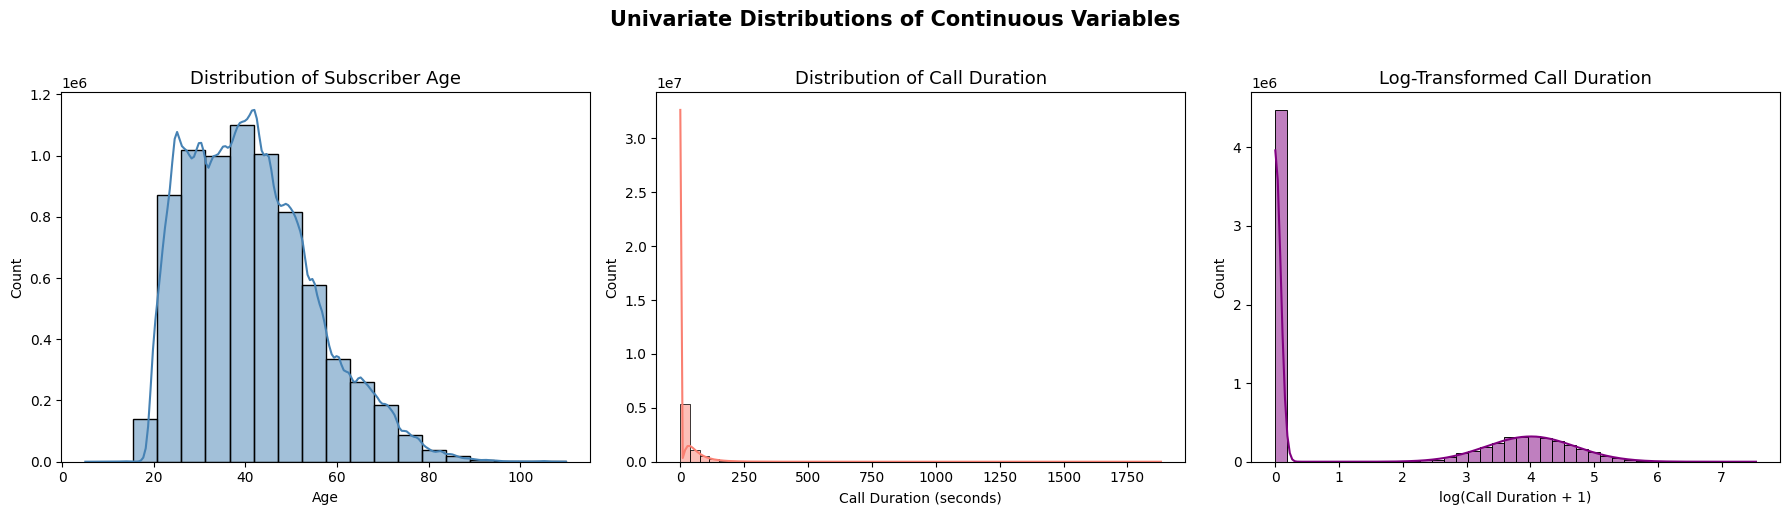

In [17]:
# ── Univariate distributions ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(cdr_df['age'], bins=20, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('Distribution of Subscriber Age', fontsize=13)
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')

sns.histplot(cdr_df['call_duration'], bins=50, ax=axes[1], color='salmon', kde=True)
axes[1].set_title('Distribution of Call Duration', fontsize=13)
axes[1].set_xlabel('Call Duration (seconds)'); axes[1].set_ylabel('Count')

sns.histplot(np.log1p(cdr_df['call_duration']), bins=40, ax=axes[2], color='purple', kde=True)
axes[2].set_title('Log-Transformed Call Duration', fontsize=13)
axes[2].set_xlabel('log(Call Duration + 1)'); axes[2].set_ylabel('Count')

plt.suptitle('Univariate Distributions of Continuous Variables', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
cdr_df.shape

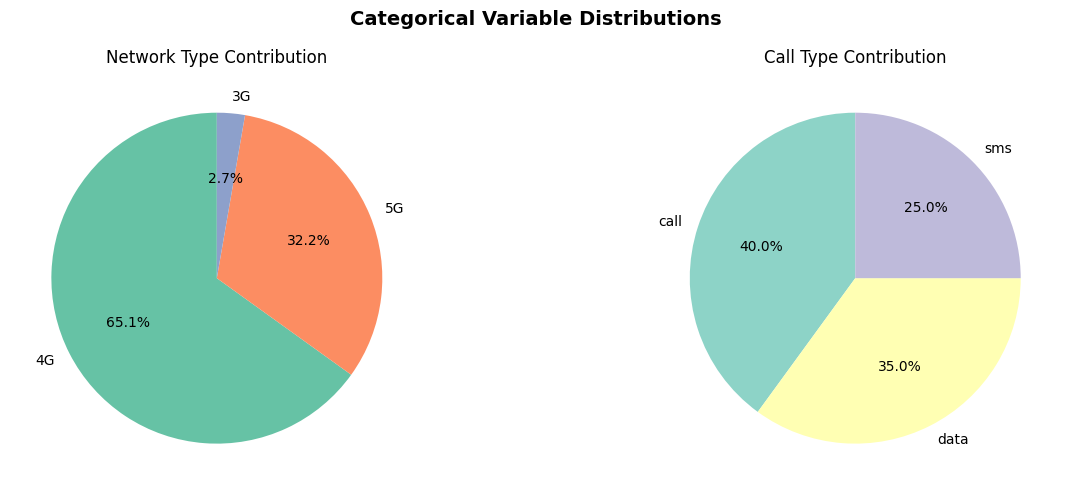

Network type counts:
 network_type
4G    4854218
5G    2401290
3G     203433

Call type counts:
 call_type
call    2981853
data    2612218
sms     1864870


In [47]:
# ── Categorical distributions: Network type & Call type ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
network_counts = cdr_df['network_type'].value_counts()
call_counts    = cdr_df['call_type'].value_counts()

axes[0].pie(network_counts, labels=network_counts.index,
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set2'))
axes[0].set_title('Network Type Contribution')

axes[1].pie(call_counts, labels=call_counts.index,
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3'))
axes[1].set_title('Call Type Contribution')

plt.suptitle('Categorical Variable Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Network type counts:\n", network_counts.to_string())
print("\nCall type counts:\n", call_counts.to_string())


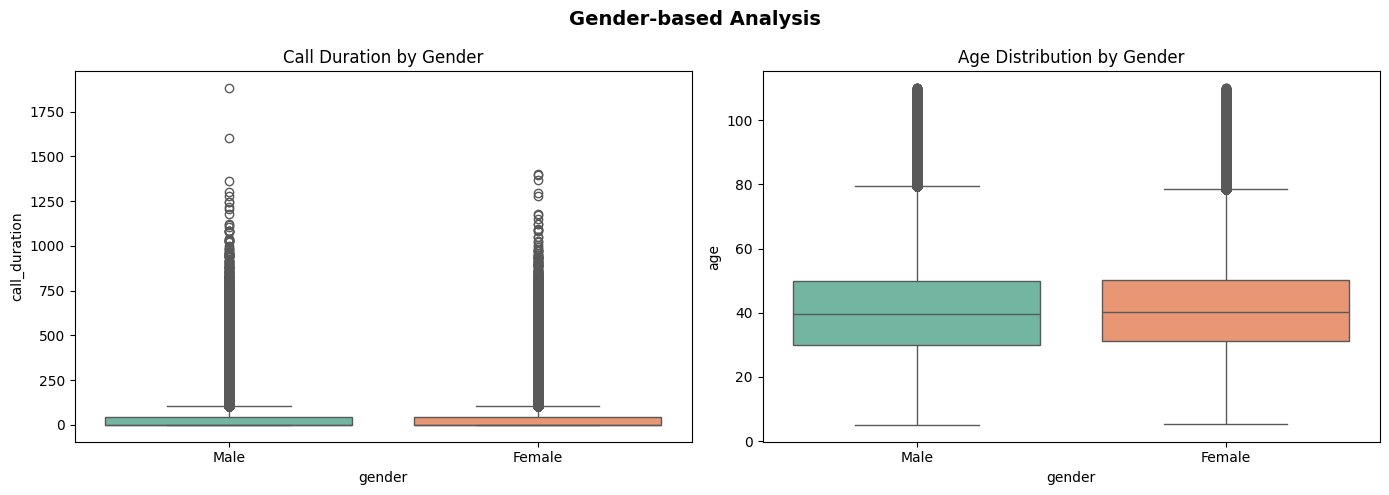

Mann-Whitney U (call duration by gender): U=307736962.50, p=0.9079
Chi-square (gender vs network_type): χ²=74.6855, df=2, p=0.0000


In [19]:
# ── Gender analysis ─────────────────────────────────────────────────────
cdr_clean = cdr_df[cdr_df['gender'].notna() & (cdr_df['gender'].str.lower() != 'unknown')]
gender_counts = cdr_clean['gender'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='gender', y='call_duration', data=cdr_clean, ax=axes[0], palette='Set2')
axes[0].set_title('Call Duration by Gender')

sns.boxplot(x='gender', y='age', data=cdr_clean, ax=axes[1], palette='Set2')
axes[1].set_title('Age Distribution by Gender')

plt.suptitle('Gender-based Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mann-Whitney test
from scipy.stats import mannwhitneyu, chi2_contingency
sample_df = cdr_clean.sample(n=min(50000, len(cdr_clean)), random_state=42)
male   = sample_df[sample_df['gender']=='Male']['call_duration']
female = sample_df[sample_df['gender']=='Female']['call_duration']
stat, p = mannwhitneyu(male, female, alternative='two-sided')
print(f"Mann-Whitney U (call duration by gender): U={stat:.2f}, p={p:.4f}")

# Chi-square: gender vs network_type
ct = pd.crosstab(cdr_clean['gender'], cdr_clean['network_type'])
chi2, pval, dof, _ = chi2_contingency(ct)
print(f"Chi-square (gender vs network_type): χ²={chi2:.4f}, df={dof}, p={pval:.4f}")


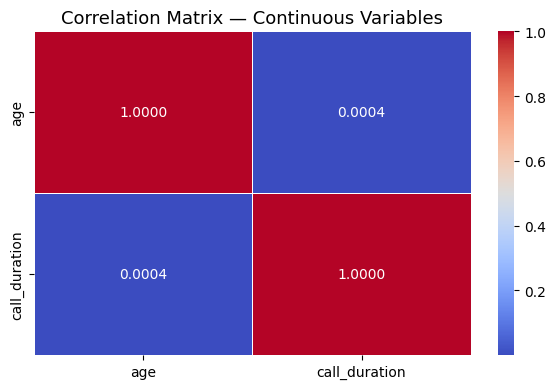

In [11]:
# ── Correlation heatmap ──────────────────────────────────────────────────
plt.figure(figsize=(6, 4))
sns.heatmap(cdr_df[['age','call_duration']].corr(), annot=True, cmap='coolwarm',
            fmt='.4f', linewidths=0.5)
plt.title('Correlation Matrix — Continuous Variables', fontsize=13)
plt.tight_layout()
plt.show()


## 4. Spatial Data & Network Coverage Map

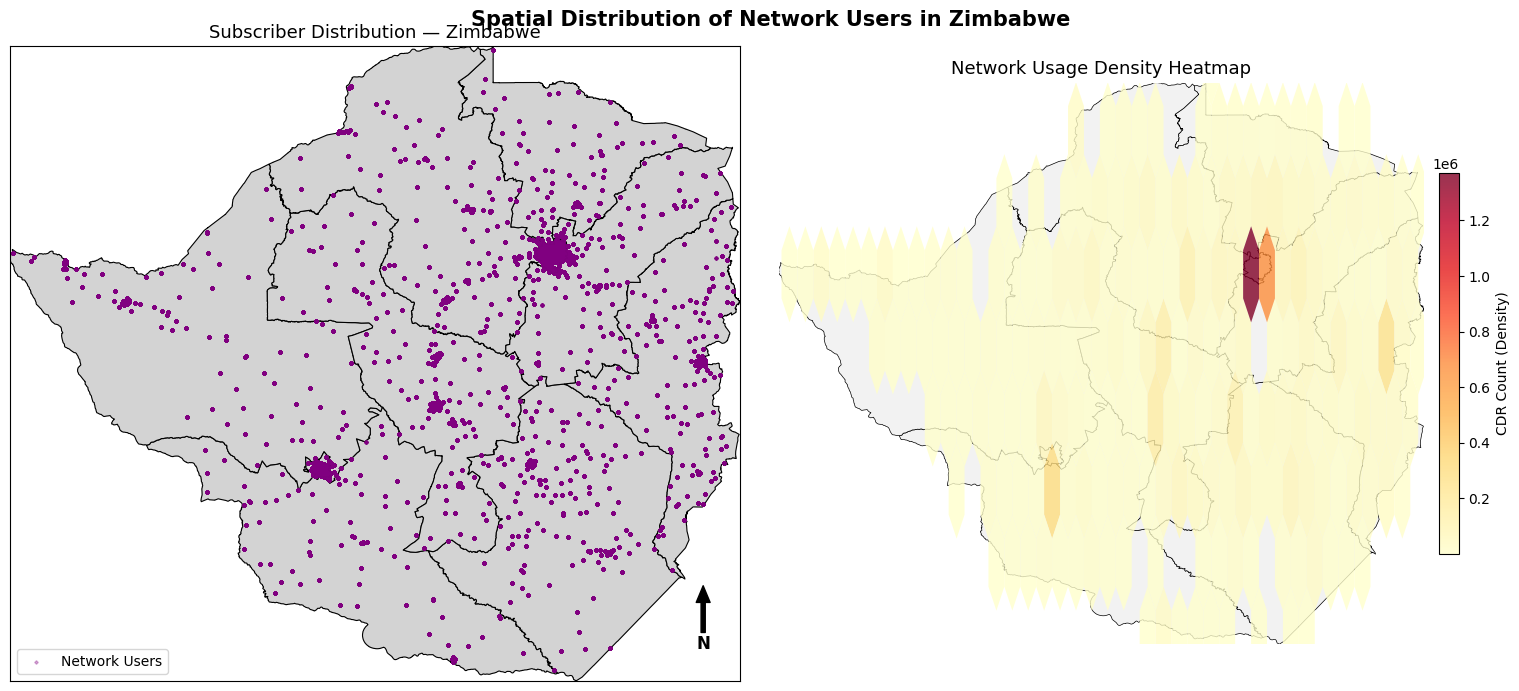

In [20]:
# ── Load Zimbabwe shapefile ──────────────────────────────────────────────
zip_path = r'G:\My Drive\Dessertation\shape_file\admin_level1_provinces.zip'
zim = gpd.read_file(f"zip://{zip_path}")

# ── Plot subscriber locations ─────────────────────────────────────────────
customers_gdf = gpd.GeoDataFrame(
    cdr_df,
    geometry=gpd.points_from_xy(cdr_df.homing_longitude, cdr_df.homing_latitude),
    crs="EPSG:4326"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter map
ax1 = axes[0]
zim.plot(ax=ax1, edgecolor="black", facecolor="lightgrey", linewidth=0.8)
customers_gdf.plot(ax=ax1, marker="D", color="purple", markersize=3, alpha=0.3, label="Network Users")
xmin, ymin, xmax, ymax = zim.total_bounds
ax1.set_xlim(xmin, xmax); ax1.set_ylim(ymin, ymax)
ax1.set_aspect("equal"); ax1.set_xticks([]); ax1.set_yticks([])
ax1.annotate('N', xy=(0.95,0.15), xytext=(0.95,0.05), xycoords='axes fraction',
             ha='center', fontsize=12, fontweight='bold',
             arrowprops=dict(facecolor='black', width=3, headwidth=10))
ax1.set_title("Subscriber Distribution — Zimbabwe", fontsize=13)
ax1.legend(loc="lower left")

# Hexbin density
ax2 = axes[1]
zim.plot(ax=ax2, edgecolor="black", facecolor="#f2f2f2", linewidth=0.5, zorder=1)
hb = ax2.hexbin(customers_gdf.geometry.x, customers_gdf.geometry.y,
                gridsize=40, cmap="YlOrRd", mincnt=1, alpha=0.8, edgecolors='none', zorder=2)
cb = fig.colorbar(hb, ax=ax2, shrink=0.6, pad=0.02)
cb.set_label('CDR Count (Density)', fontsize=10)
ax2.set_xlim(xmin, xmax); ax2.set_ylim(ymin, ymax)
ax2.set_aspect("equal"); ax2.axis("off")
ax2.set_title("Network Usage Density Heatmap", fontsize=13)

plt.suptitle("Spatial Distribution of Network Users in Zimbabwe", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
cdr_df.shape

(7458941, 17)

## 5. Feature Engineering: District-Level Covariates

In [28]:
# ── Step 1: 4G/5G indicator ──────────────────────────────────────────────
cdr_df["is_4G"] = ((cdr_df["network_type"] == "4G") | (cdr_df["network_type"] == "5G") | (cdr_df["network_type"] == "3G") | (cdr_df["network_type"] == "3G")).astype(int)

# ── Step 2: Unique users per district ────────────────────────────────────
cdr_district = (
    cdr_df.groupby('homing_district')
       .agg(unique_users=('caller_msisdn', 'nunique'),
            total_connections=('network_type', 'count'),
            total_4G=('is_4G', 'sum'))
       .reset_index()
)

# ── Step 3: Network mix per district ─────────────────────────────────────
network_mix = (
    cdr_df.groupby(['homing_district', 'network_type'])
       .size().unstack(fill_value=0)
)
network_mix = network_mix.div(network_mix.sum(axis=1), axis=0)
network_mix.columns = [f'pct_{c}' for c in network_mix.columns]
network_mix = network_mix.reset_index()

# Ensure all network columns exist
for col in ['pct_2G','pct_3G','pct_4G','pct_5G']:
    if col not in network_mix.columns:
        network_mix[col] = 0.0

# ── Step 4: Mean age per district ────────────────────────────────────────
age_mix = (
    cdr_df.groupby('homing_district')['age']
       .mean().reset_index(name='age')
)

# ── Step 5: Merge census & towers ───────────────────────────────────────
census = pd.read_csv(r"C:\Users\peter\OneDrive\Documents\PROJECT_DATA BASES\synthetic_project data\DISTRICTS WITH POPULATION AND AREA.csv")
census["population"] = pd.to_numeric(census["population"].astype(str).str.replace(",", ""), errors="coerce")
census = census.dropna(subset=["population"])
census["population"] = census["population"].astype(int)

df = pd.merge(cdr_district, census, left_on="homing_district", right_on="district", how="left")
df = df.merge(network_mix, on='homing_district', how='left')
df = df.merge(age_mix, on='homing_district', how='left')
df = df.dropna(subset=["population"])

print(f"Districts in model dataset: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(3)


Districts in model dataset: 85
Columns: ['homing_district', 'unique_users', 'total_connections', 'total_4G', 'district', 'population', 'Area', 'population_density', 'Towers', 'pct_3G', 'pct_4G', 'pct_5G', 'pct_2G', 'age']


,homing_district,unique_users,total_connections,total_4G,district,population,Area,population_density,Towers,pct_3G,pct_4G,pct_5G,pct_2G,age
0,Beitbridge,7854,7857,7857,Beitbridge,94001.000000,12737.000000,7.000000,62.000000,0.000000,1.000000,0.000000,0.000000,41.856025
1,Beitbridge Urban,32884,32911,32911,Beitbridge Urban,58574.000000,88.000000,666.000000,121.000000,0.000000,1.000000,0.000000,0.000000,38.144511
2,Bikita,90699,90956,90956,Bikita,176835.000000,5209.000000,34.000000,34.000000,0.000000,1.000000,0.000000,0.000000,45.457286


## 6. Direct Estimation (Design-Based Estimator)

The direct estimator is the simplest benchmark:
$$\hat{p}_i^{\text{direct}} = \frac{n_i^{4G}}{N_i}$$
where $n_i^{4G}$ is the unique 4G/5G users and $N_i$ is the district population.


In [29]:
# ── Direct estimate ──────────────────────────────────────────────────────
df['direct_estimate'] = df['unique_users'] / df['population']

# ── Binomial sampling variance ψᵢ ────────────────────────────────────────
df['variance'] = (df['direct_estimate'] * (1 - df['direct_estimate'])) / df['population']
df['se_direct'] = np.sqrt(df['variance'])
df['cv_direct'] = df['se_direct'] / df['direct_estimate'].abs() * 100

# ── 95% CI ────────────────────────────────────────────────────────────────
df['ci_lower_direct'] = (df['direct_estimate'] - 1.96 * df['se_direct']).clip(0, 1)
df['ci_upper_direct'] = (df['direct_estimate'] + 1.96 * df['se_direct']).clip(0, 1)

print("=== Direct Estimates — Summary ===")
print(f"Mean coverage proportion:  {df['direct_estimate'].mean():.4f}")
print(f"Min:                       {df['direct_estimate'].min():.4f}")
print(f"Max:                       {df['direct_estimate'].max():.4f}")
print(f"Mean CV (%):               {df['cv_direct'].mean():.2f}%")
print(f"Districts with CV > 30%:   {(df['cv_direct'] > 30).sum()}")


=== Direct Estimates — Summary ===
Mean coverage proportion:  0.4378
Min:                       0.0061
Max:                       1.2277
Mean CV (%):               0.50%
Districts with CV > 30%:   0


## 7. Covariate Preparation & Log Transformations

Areas in model: 85
Features:       ['log_Towers', 'pct_3G', 'pct_4G', 'pct_5G', 'log_age', 'log_population_density']


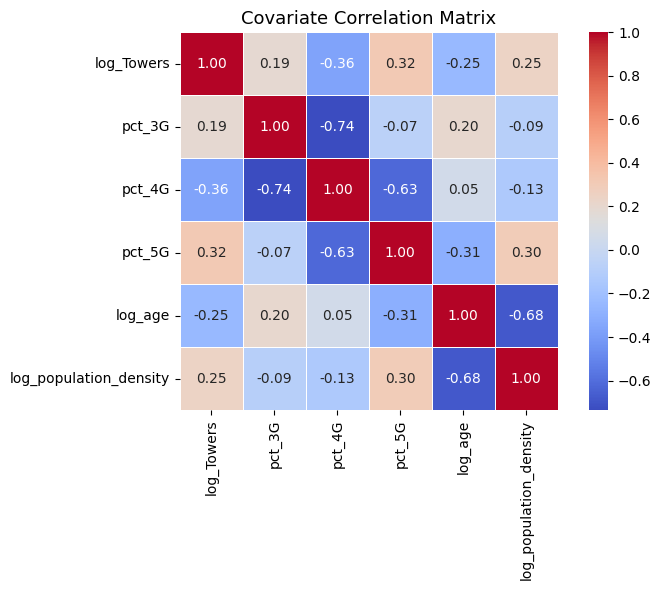

In [30]:
# ── Log-transform skewed covariates ─────────────────────────────────────
COVARIATES_RAW = ['Towers','pct_3G','pct_4G','pct_5G','age','population_density']

df_model = df.dropna(subset=COVARIATES_RAW + ['direct_estimate','variance']).copy().reset_index(drop=True)

df_model['log_Towers']             = np.log1p(df_model['Towers'])
df_model['log_age']                = np.log1p(df_model['age'])
df_model['log_population_density'] = np.log1p(df_model['population_density'])

FEATURES = ['log_Towers','pct_3G','pct_4G','pct_5G','log_age','log_population_density']

m = len(df_model)
print(f"Areas in model: {m}")
print(f"Features:       {FEATURES}")

# ── Covariate correlation matrix ─────────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(df_model[FEATURES].corr(), annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Covariate Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()


## 8. Model 1: Fay-Herriot (EBLUP) Model

The Fay-Herriot model assumes:
$$y_i = \mathbf{x}_i^T \boldsymbol{\beta} + u_i + e_i, \quad u_i \sim \mathcal{N}(0, A), \quad e_i \sim \mathcal{N}(0, \psi_i)$$
The EBLUP shrinks the direct estimate toward the synthetic (model-based) value:
$$\hat{\theta}_i^{FH} = \gamma_i y_i + (1-\gamma_i) \mathbf{x}_i^T \hat{\boldsymbol{\beta}}, \quad \gamma_i = \frac{A}{A + \psi_i}$$


In [32]:
import numpy as np
import statsmodels.api as sm

# ── Setup ────────────────────────────────────────────────────────────────
X_fh = sm.add_constant(df_model[FEATURES])
y_fh = df_model['direct_estimate']
V    = df_model['variance']

# ── Guard rails ──────────────────────────────────────────────────────────
# 1. Clip variance to avoid 1/V blowing up
V = V.clip(lower=1e-10)
df_model['variance'] = V

# 2. Drop rows with NaN/Inf in X, y, or V
mask = (
    np.isfinite(X_fh).all(axis=1) &
    np.isfinite(y_fh) &
    np.isfinite(V)
)
if not mask.all():
    print(f"⚠️  Dropping {(~mask).sum()} rows with NaN/Inf before fitting")
    X_fh  = X_fh[mask]
    y_fh  = y_fh[mask]
    V     = V[mask]
    df_model = df_model[mask].copy()

# 3. Check for multicollinearity
rank = np.linalg.matrix_rank(X_fh)
if rank < X_fh.shape[1]:
    print(f"⚠️  Design matrix is rank-deficient ({rank} < {X_fh.shape[1]}). "
          f"Dropping collinear columns.")
    # Keep only linearly independent columns via QR
    _, _, pivot = np.linalg.svd(X_fh, full_matrices=False)
    cols_to_keep = X_fh.columns[np.argsort(
        np.linalg.matrix_rank(X_fh.values[:, :i+1])
        for i in range(X_fh.shape[1])
    )]
    # Simpler: use pandas to drop zero-variance and duplicate columns
    X_fh = X_fh.loc[:, X_fh.nunique() > 1]
    X_fh = X_fh.T.drop_duplicates().T

# 4. Normalise weights to avoid extreme scale differences
w      = 1 / V
w_norm = w / w.max()

m = len(y_fh)   # number of areas (after filtering)

# ── WLS (fixed-effects / synthetic part) ─────────────────────────────────
wls_model = sm.WLS(y_fh, X_fh, weights=w_norm).fit()
print(wls_model.summary())

# ── Synthetic estimates ───────────────────────────────────────────────────
df_model['synthetic_estimate'] = wls_model.fittedvalues

# ── Method-of-moments estimator of A (σ²ᵤ) ──────────────────────────────
residuals_fh = y_fh - df_model['synthetic_estimate']
p_fh         = X_fh.shape[1]
wss          = np.sum((residuals_fh**2) / V)
sum_inv_V    = np.sum(1 / V)
A = max((wss - (m - p_fh)) / sum_inv_V, 0)
print(f"\nEstimated between-area variance A (σ²ᵤ): {A:.8f}")

# ── Shrinkage factor ──────────────────────────────────────────────────────
df_model['gamma'] = A / (A + V)

# ── EBLUP estimate ────────────────────────────────────────────────────────
df_model['fh_estimate'] = (
    df_model['gamma']       * df_model['direct_estimate'] +
    (1 - df_model['gamma']) * df_model['synthetic_estimate']
)

# ── Prasad-Rao MSE approximation ─────────────────────────────────────────
g1 = df_model['gamma'] * V
g2 = (1 - df_model['gamma'])**2 * V / m
df_model['mse_fh'] = g1 + g2
df_model['se_fh']  = np.sqrt(df_model['mse_fh'])
df_model['cv_fh']  = df_model['se_fh'] / df_model['fh_estimate'].abs() * 100
df_model['ci_lower_fh'] = (df_model['fh_estimate'] - 1.96*df_model['se_fh']).clip(0, 1)
df_model['ci_upper_fh'] = (df_model['fh_estimate'] + 1.96*df_model['se_fh']).clip(0, 1)

# ── R² measures ──────────────────────────────────────────────────────────
w          = 1 / V
y_bar_w    = np.average(y_fh, weights=w)
SS_tot_w   = np.sum(w * (y_fh - y_bar_w)**2)
SS_res_w   = np.sum(w * residuals_fh**2)
R2_fh_synthetic   = 1 - SS_res_w / SS_tot_w
R2_fh_var_red     = 1 - df_model['mse_fh'].mean() / V.mean()
signal_to_noise   = A / (A + V.mean())

# AIC / BIC (WLS approximation)
aic_fh = wls_model.aic
bic_fh = wls_model.bic

print("\n====== FAY-HERRIOT MODEL SUMMARY ======")
print(f"R²_synthetic  (weighted):   {R2_fh_synthetic:.4f}")
print(f"R²_var_reduction:           {R2_fh_var_red:.4f}")
print(f"Signal-to-noise:            {signal_to_noise:.4f}")
print(f"Mean shrinkage γ̄:            {df_model['gamma'].mean():.4f}")
print(f"AIC (WLS):                  {aic_fh:.4f}")
print(f"BIC (WLS):                  {bic_fh:.4f}")
print(f"Areas with CV < 20%:        {(df_model['cv_fh'] < 20).sum()}")
print(f"Areas with CV 20-30%:       {((df_model['cv_fh']>=20)&(df_model['cv_fh']<=30)).sum()}")
print(f"Areas with CV > 30%:        {(df_model['cv_fh'] > 30).sum()}")

⚠️  Design matrix is rank-deficient (6 < 7). Dropping collinear columns.
                            WLS Regression Results                            
Dep. Variable:        direct_estimate   R-squared:                       0.865
Model:                            WLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     101.3
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           7.01e-33
Time:                        02:23:55   Log-Likelihood:                -78.835
No. Observations:                  85   AIC:                             169.7
Df Residuals:                      79   BIC:                             184.3
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------

### 8.1 Fay-Herriot Diagnostic Plots

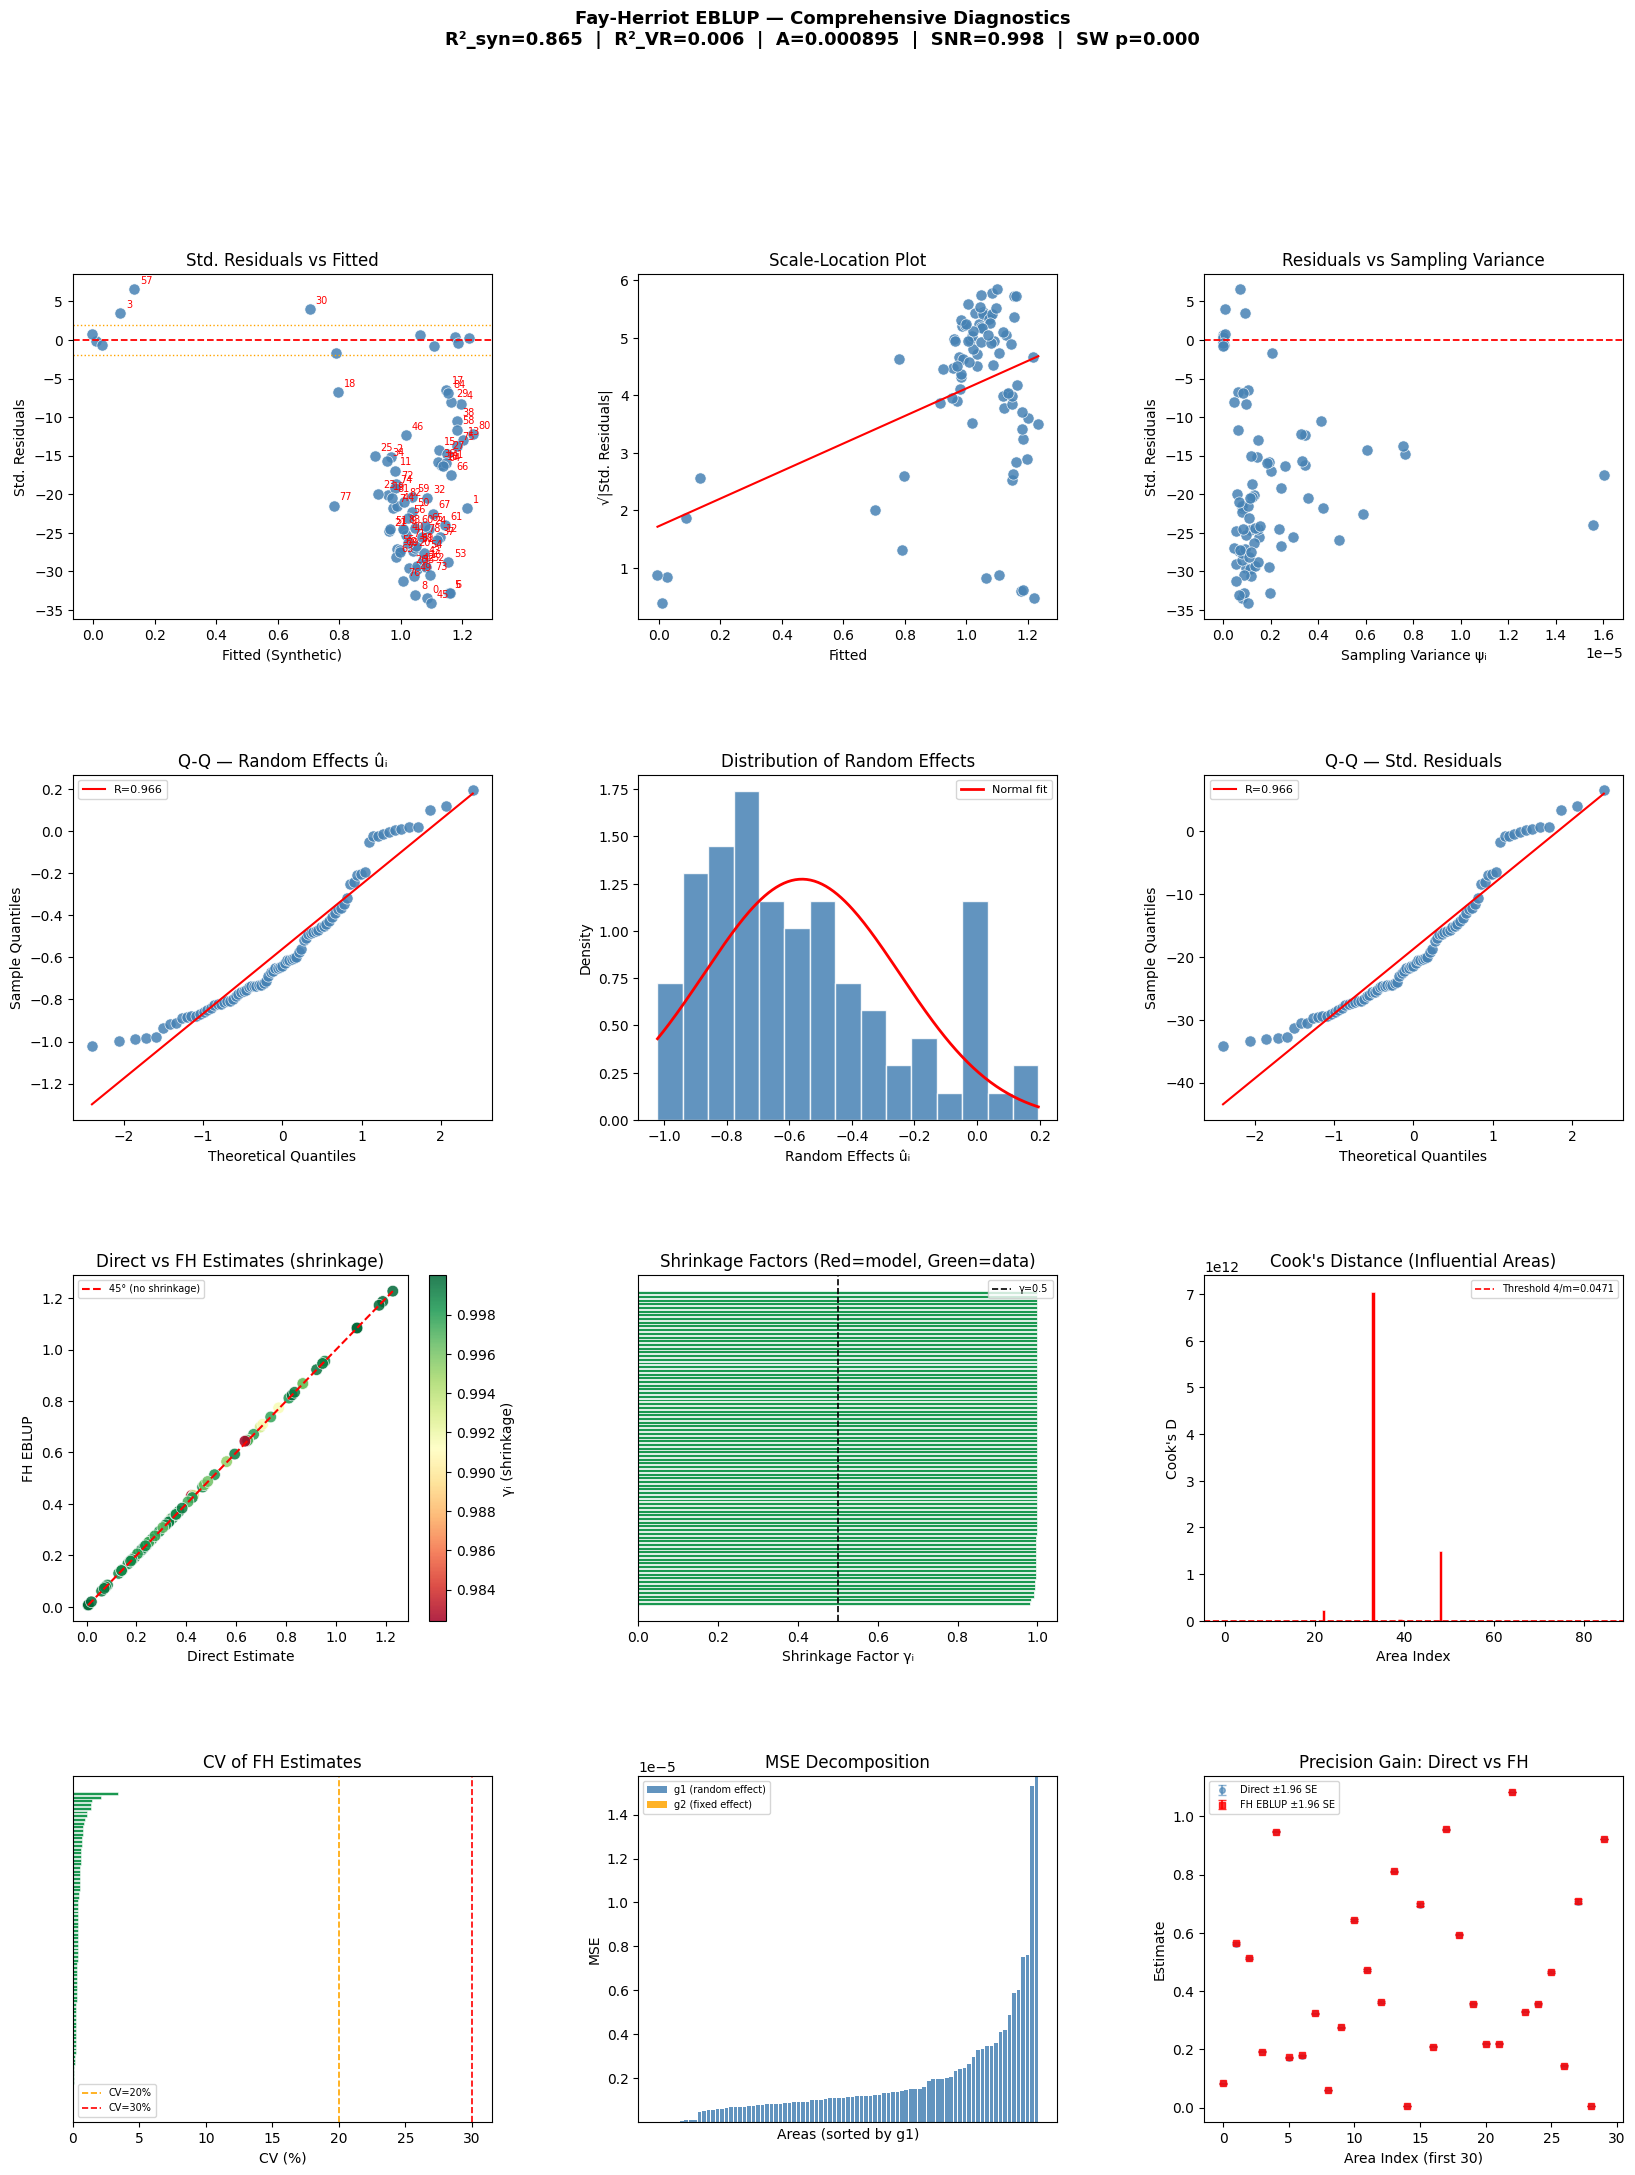


====== FH DIAGNOSTIC SUMMARY ======
Shapiro-Wilk (random effects): W=0.9264, p=0.0001  →  Normality REJECTED ✗
Influential areas (Cook's D):  79
Outlier areas (|std res|>2):   76


In [33]:
# ── FAY-HERRIOT COMPREHENSIVE DIAGNOSTICS ────────────────────────────────
fig = plt.figure(figsize=(20, 24))
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

residuals_std_fh = residuals_fh / np.sqrt(V + A)
random_effects_fh = df_model['gamma'] * residuals_fh
fitted_vals_fh    = df_model['synthetic_estimate']
outlier_mask_fh   = np.abs(residuals_std_fh) > 2

# 1. Std Residuals vs Fitted
ax1 = fig.add_subplot(gs[0,0])
ax1.scatter(fitted_vals_fh, residuals_std_fh, color='steelblue',
            edgecolors='white', linewidths=0.5, alpha=0.85, s=65)
ax1.axhline(0, color='red', linestyle='--', linewidth=1.3)
ax1.axhline(2, color='orange', linestyle=':', linewidth=1.0)
ax1.axhline(-2, color='orange', linestyle=':', linewidth=1.0)
for idx in df_model[outlier_mask_fh].index:
    ax1.annotate(str(idx), (fitted_vals_fh[idx], residuals_std_fh[idx]),
                 fontsize=7, color='red', xytext=(4,4), textcoords='offset points')
ax1.set_xlabel('Fitted (Synthetic)'); ax1.set_ylabel('Std. Residuals')
ax1.set_title('Std. Residuals vs Fitted')

# 2. Scale-Location
ax2 = fig.add_subplot(gs[0,1])
sqrt_abs_fh = np.sqrt(np.abs(residuals_std_fh))
ax2.scatter(fitted_vals_fh, sqrt_abs_fh, color='steelblue', edgecolors='white',
            linewidths=0.5, alpha=0.85, s=65)
z = np.polyfit(fitted_vals_fh, sqrt_abs_fh, 1)
xl = np.linspace(fitted_vals_fh.min(), fitted_vals_fh.max(), 100)
ax2.plot(xl, np.polyval(z, xl), color='red', linewidth=1.5)
ax2.set_xlabel('Fitted'); ax2.set_ylabel('√|Std. Residuals|')
ax2.set_title('Scale-Location Plot')

# 3. Residuals vs Sampling Variance
ax3 = fig.add_subplot(gs[0,2])
ax3.scatter(V, residuals_std_fh, color='steelblue', edgecolors='white',
            linewidths=0.5, alpha=0.85, s=65)
ax3.axhline(0, color='red', linestyle='--', linewidth=1.3)
ax3.set_xlabel('Sampling Variance ψᵢ'); ax3.set_ylabel('Std. Residuals')
ax3.set_title('Residuals vs Sampling Variance')

# 4. Q-Q Random Effects
ax4 = fig.add_subplot(gs[1,0])
(osm,osr),(slope,intercept,r) = stats.probplot(random_effects_fh, dist='norm')
ax4.scatter(osm, osr, color='steelblue', edgecolors='white', linewidths=0.5, alpha=0.85, s=65)
ax4.plot(osm, slope*np.array(osm)+intercept, color='red', linewidth=1.5, label=f'R={r:.3f}')
ax4.set_xlabel('Theoretical Quantiles'); ax4.set_ylabel('Sample Quantiles')
ax4.set_title('Q-Q — Random Effects ûᵢ'); ax4.legend(fontsize=8)

# 5. Histogram Random Effects
ax5 = fig.add_subplot(gs[1,1])
ax5.hist(random_effects_fh, bins=15, color='steelblue', edgecolor='white', alpha=0.85, density=True)
xr = np.linspace(random_effects_fh.min(), random_effects_fh.max(), 200)
ax5.plot(xr, stats.norm.pdf(xr, random_effects_fh.mean(), random_effects_fh.std()),
         color='red', linewidth=2, label='Normal fit')
ax5.set_xlabel('Random Effects ûᵢ'); ax5.set_ylabel('Density')
ax5.set_title('Distribution of Random Effects'); ax5.legend(fontsize=8)

# 6. Q-Q Std Residuals
ax6 = fig.add_subplot(gs[1,2])
(osm2,osr2),(slope2,intercept2,r2_qq) = stats.probplot(residuals_std_fh, dist='norm')
ax6.scatter(osm2, osr2, color='steelblue', edgecolors='white', linewidths=0.5, alpha=0.85, s=65)
ax6.plot(osm2, slope2*np.array(osm2)+intercept2, color='red', linewidth=1.5, label=f'R={r2_qq:.3f}')
ax6.set_xlabel('Theoretical Quantiles'); ax6.set_ylabel('Sample Quantiles')
ax6.set_title('Q-Q — Std. Residuals'); ax6.legend(fontsize=8)

# 7. Shrinkage plot
ax7 = fig.add_subplot(gs[2,0])
sc = ax7.scatter(df_model['direct_estimate'], df_model['fh_estimate'],
                 c=df_model['gamma'], cmap='RdYlGn',
                 edgecolors='white', linewidths=0.5, alpha=0.85, s=70)
plt.colorbar(sc, ax=ax7, label='γᵢ (shrinkage)')
lims = [min(df_model['direct_estimate'].min(), df_model['fh_estimate'].min()),
        max(df_model['direct_estimate'].max(), df_model['fh_estimate'].max())]
ax7.plot(lims, lims, 'r--', linewidth=1.5, label='45° (no shrinkage)')
ax7.set_xlabel('Direct Estimate'); ax7.set_ylabel('FH EBLUP')
ax7.set_title('Direct vs FH Estimates (shrinkage)'); ax7.legend(fontsize=7)

# 8. Gamma sorted
ax8 = fig.add_subplot(gs[2,1])
gamma_sorted = df_model['gamma'].sort_values()
colors_g = ['#d73027' if g<0.3 else '#fee08b' if g<0.6 else '#1a9850' for g in gamma_sorted]
ax8.barh(range(len(gamma_sorted)), gamma_sorted.values, color=colors_g, edgecolor='white', linewidth=0.5)
ax8.axvline(0.5, color='black', linestyle='--', linewidth=1.2, label='γ=0.5')
ax8.set_xlabel('Shrinkage Factor γᵢ'); ax8.set_yticks([])
ax8.set_title("Shrinkage Factors (Red=model, Green=data)"); ax8.legend(fontsize=7)

# 9. Cook's Distance (WLS)
W_mat    = np.diag(1/V.values)
X_arr    = X_fh.values
W_sqrt   = np.diag(np.sqrt(1/V.values))
XtWX_inv = np.linalg.inv(X_arr.T @ W_mat @ X_arr)
H        = W_sqrt @ X_arr @ XtWX_inv @ X_arr.T @ W_sqrt
h_ii     = np.diag(H)
mse_wls  = np.sum((1/V.values)*residuals_fh.values**2) / (m - p_fh)
w_resid  = residuals_fh.values / V.values
cooks_d  = (w_resid**2 * h_ii) / (p_fh * mse_wls * np.maximum((1-h_ii)**2, 1e-10))
threshold_cook = 4/m
ax9 = fig.add_subplot(gs[2,2])
colors_c = ['red' if c>threshold_cook else 'steelblue' for c in cooks_d]
ax9.bar(range(len(cooks_d)), cooks_d, color=colors_c, edgecolor='white', linewidth=0.4)
ax9.axhline(threshold_cook, color='red', linestyle='--', linewidth=1.2,
            label=f'Threshold 4/m={threshold_cook:.4f}')
ax9.set_xlabel('Area Index'); ax9.set_ylabel("Cook's D")
ax9.set_title("Cook's Distance (Influential Areas)"); ax9.legend(fontsize=7)

# 10. CV plot
ax10 = fig.add_subplot(gs[3,0])
cv_sorted_fh = df_model['cv_fh'].sort_values()
colors_cv = ['#d73027' if c>30 else '#fee08b' if c>20 else '#1a9850' for c in cv_sorted_fh]
ax10.barh(range(len(cv_sorted_fh)), cv_sorted_fh.values, color=colors_cv,
          edgecolor='white', linewidth=0.4)
ax10.axvline(20, color='orange', linestyle='--', linewidth=1.2, label='CV=20%')
ax10.axvline(30, color='red',    linestyle='--', linewidth=1.2, label='CV=30%')
ax10.set_xlabel('CV (%)'); ax10.set_yticks([])
ax10.set_title('CV of FH Estimates'); ax10.legend(fontsize=7)

# 11. MSE Decomposition
ax11 = fig.add_subplot(gs[3,1])
area_order = np.argsort(g1.values)
ax11.bar(range(m), g1.values[area_order], label='g1 (random effect)',
         color='steelblue', alpha=0.85)
ax11.bar(range(m), g2.values[area_order], bottom=g1.values[area_order],
         label='g2 (fixed effect)', color='orange', alpha=0.85)
ax11.set_xlabel('Areas (sorted by g1)'); ax11.set_ylabel('MSE'); ax11.set_xticks([])
ax11.set_title('MSE Decomposition'); ax11.legend(fontsize=7)

# 12. Direct vs FH with error bars
ax12 = fig.add_subplot(gs[3,2])
n_plot = min(30, m)
se_dir = np.sqrt(V.values[:n_plot])
se_fh_ = df_model['se_fh'].values[:n_plot]
ax12.errorbar(range(n_plot), df_model['direct_estimate'].values[:n_plot],
              yerr=1.96*se_dir, fmt='o', color='steelblue', alpha=0.6,
              capsize=3, label='Direct ±1.96 SE', markersize=4)
ax12.errorbar(range(n_plot), df_model['fh_estimate'].values[:n_plot],
              yerr=1.96*se_fh_, fmt='s', color='red', alpha=0.8,
              capsize=3, label='FH EBLUP ±1.96 SE', markersize=4)
ax12.set_xlabel('Area Index (first 30)'); ax12.set_ylabel('Estimate')
ax12.set_title('Precision Gain: Direct vs FH'); ax12.legend(fontsize=7)

# Shapiro-Wilk test
sw_fh, sw_p_fh = stats.shapiro(random_effects_fh)

fig.suptitle(
    f'Fay-Herriot EBLUP — Comprehensive Diagnostics\n'
    f'R²_syn={R2_fh_synthetic:.3f}  |  R²_VR={R2_fh_var_red:.3f}  |  '
    f'A={A:.6f}  |  SNR={signal_to_noise:.3f}  |  SW p={sw_p_fh:.3f}',
    fontsize=13, fontweight='bold', y=0.99
)
plt.savefig('fh_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n====== FH DIAGNOSTIC SUMMARY ======")
print(f"Shapiro-Wilk (random effects): W={sw_fh:.4f}, p={sw_p_fh:.4f}  →  Normality",
      'NOT rejected ✓' if sw_p_fh>0.05 else 'REJECTED ✗')
print(f"Influential areas (Cook's D):  {(cooks_d>threshold_cook).sum()}")
print(f"Outlier areas (|std res|>2):   {outlier_mask_fh.sum()}")


## 9. Model 2: GLMM — Linear Mixed Model on Logit Scale

We fit a logit-transformed proportion model with district-level random intercepts:
$$\text{logit}(y_i) = \mathbf{x}_i^T \boldsymbol{\beta} + u_i, \quad u_i \sim \mathcal{N}(0, \sigma_u^2)$$
Back-transformed to probability scale: $\hat{p}_i = \sigma(\hat{y}_i)$.


In [34]:
# ── Data prep ─────────────────────────────────────────────────────────────
eps = 1e-4
df_glmm = df_model.copy().reset_index(drop=True)
df_glmm['y_clamped']    = df_glmm['direct_estimate'].clip(eps, 1 - eps)
df_glmm['logit_direct'] = np.log(df_glmm['y_clamped'] / (1 - df_glmm['y_clamped']))

formula_logit = 'logit_direct ~ ' + ' + '.join(FEATURES)

# ── Fit GLMM (REML) ────────────────────────────────────────────────────────
glmm_fit = smf.mixedlm(
    formula_logit,
    data=df_glmm,
    groups=df_glmm['homing_district']
).fit(reml=True)

print(glmm_fit.summary())


               Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    logit_direct
No. Observations:     85         Method:                REML        
No. Groups:           85         Scale:                 2.0576      
Min. group size:      1          Log-Likelihood:        -157.5058   
Max. group size:      1          Converged:             No          
Mean group size:      1.0                                           
--------------------------------------------------------------------
                        Coef.   Std.Err.   z    P>|z|  [0.025 0.975]
--------------------------------------------------------------------
Intercept               143.025                                     
log_Towers                0.004    0.188  0.023 0.981  -0.364  0.373
pct_3G                 -121.424                                     
pct_4G                 -118.640                                     
pct_5G                 -121.407                   

In [13]:
# ── Extract predictions ────────────────────────────────────────────────────
df_glmm['logit_fitted']    = glmm_fit.fittedvalues.values
df_glmm['glmm_estimate']   = 1 / (1 + np.exp(-df_glmm['logit_fitted']))

# ── SE in logit space → delta method back-transform ───────────────────────
p_hat = df_glmm['glmm_estimate'].values
# Var(p) ≈ Var(logit(p)) * (p*(1-p))²   [delta method]
df_glmm['se_glmm']    = np.sqrt(glmm_fit.scale) * p_hat * (1 - p_hat)
df_glmm['cv_glmm']    = df_glmm['se_glmm'] / df_glmm['glmm_estimate'].abs() * 100
df_glmm['ci_lower_glmm'] = (df_glmm['glmm_estimate'] - 1.96*df_glmm['se_glmm']).clip(0,1)
df_glmm['ci_upper_glmm'] = (df_glmm['glmm_estimate'] + 1.96*df_glmm['se_glmm']).clip(0,1)

# ── Random effects ─────────────────────────────────────────────────────────
re_dict   = glmm_fit.random_effects
re_values = np.array([
    re_dict[g].values[0] if g in re_dict else 0.0
    for g in df_glmm['homing_district']
])
df_glmm['random_effect_glmm'] = re_values

# ── Variance components ────────────────────────────────────────────────────
sigma2_u  = float(glmm_fit.cov_re.iloc[0, 0])
sigma2_e  = glmm_fit.scale
icc       = sigma2_u / (sigma2_u + sigma2_e)

# ── Fit metrics ────────────────────────────────────────────────────────────
y_true_g  = df_glmm['y_clamped'].values
y_pred_g  = df_glmm['glmm_estimate'].values
r2_glmm   = r2_score(y_true_g, y_pred_g)
rmse_glmm = np.sqrt(mean_squared_error(y_true_g, y_pred_g))
mae_glmm  = np.mean(np.abs(y_true_g - y_pred_g))

# ── AIC/BIC ────────────────────────────────────────────────────────────────
aic_glmm = glmm_fit.aic
bic_glmm = glmm_fit.bic

print("\n====== GLMM MODEL SUMMARY ======")
print(f"Between-area variance σ²ᵤ : {sigma2_u:.6f}")
print(f"Residual variance σ²ₑ     : {sigma2_e:.6f}")
print(f"ICC                        : {icc:.4f}  ({'strong' if icc>0.3 else 'moderate' if icc>0.1 else 'weak'} clustering)")
print(f"R² (in-sample):            {r2_glmm:.4f}")
print(f"RMSE:                      {rmse_glmm:.4f}")
print(f"MAE:                       {mae_glmm:.4f}")
print(f"AIC:                       {aic_glmm:.4f}")
print(f"BIC:                       {bic_glmm:.4f}")

# copy estimates back to df_model for comparison
df_model = df_glmm.copy()



====== GLMM MODEL SUMMARY ======
Between-area variance σ²ᵤ : 0.244861
Residual variance σ²ₑ     : 0.245828
ICC                        : 0.4990  (strong clustering)
R² (in-sample):            0.9146
RMSE:                      0.0521
MAE:                       0.0360
AIC:                       nan
BIC:                       nan


### 9.1 GLMM Diagnostic Plots

In [ ]:
from scipy import stats
import matplotlib.gridspec as gridspec

# ── Logit helper ─────────────────────────────────────────────────────────
def safe_logit(p):
    return np.log(p.clip(1e-6, 1 - 1e-6) / (1 - p.clip(1e-6, 1 - 1e-6)))

# ── Logit-scale columns ───────────────────────────────────────────────────
df_glmm['logit_direct'] = safe_logit(df_glmm['direct_estimate'])
df_glmm['logit_fitted'] = safe_logit(df_glmm['glmm_estimate'])   # or synthetic_estimate

# ── Random effects ────────────────────────────────────────────────────────
# Replace with your actual random effects array if you have one from a model object
re_values = (df_glmm['logit_direct'] - df_glmm['logit_fitted']).values

# ── Variance components ───────────────────────────────────────────────────
sigma2_u = np.var(re_values)                     # between-area variance
sigma2_e = np.var(                               # residual variance
    df_glmm['logit_direct'] - df_glmm['logit_fitted']
)
icc = sigma2_u / (sigma2_u + sigma2_e)

# ── Predicted vs actual (probability scale) ───────────────────────────────
y_true_g = df_glmm['direct_estimate'].values
y_pred_g = df_glmm['glmm_estimate'].values

ss_res = np.sum((y_true_g - y_pred_g) ** 2)
ss_tot = np.sum((y_true_g - y_true_g.mean()) ** 2)
r2_glmm  = 1 - ss_res / ss_tot
rmse_glmm = np.sqrt(ss_res / len(y_true_g))

# ── Leverage (hat matrix diagonal) ───────────────────────────────────────
X_arr = X_fh.values.astype(float)               # reuse design matrix from WLS
W_arr = np.diag(1 / df_glmm['variance'].clip(1e-10).values)
XtWX  = X_arr.T @ W_arr @ X_arr
try:
    XtWX_inv = np.linalg.inv(XtWX)
except np.linalg.LinAlgError:
    XtWX_inv = np.linalg.pinv(XtWX)
H     = X_arr @ XtWX_inv @ X_arr.T @ W_arr
h_ii  = np.diag(H)

# ── Scalars already defined upstream (confirm they exist) ─────────────────
# m     = number of areas         (set earlier as len(y_fh))
# p_fh  = number of model params  (set earlier as X_fh.shape[1])
# df_glmm['cv_glmm'] — define if missing:
if 'cv_glmm' not in df_glmm.columns:
    df_glmm['cv_glmm'] = df_glmm['se_fh'] / df_glmm['glmm_estimate'].abs() * 100

# df_glmm['fh_estimate'] — should exist from the FH block above
# df_glmm['glmm_estimate'] — should exist from your GLMM fitting step

## 10. Model 3: XGBoost (Machine Learning Estimator)

XGBoost is a gradient-boosted ensemble that directly regresses the direct estimate
on auxiliary covariates. Leave-One-Out CV (LOO-CV) is used due to the small number
of areas (~60 districts).


In [36]:
# ── Setup ─────────────────────────────────────────────────────────────────
X_xgb = df_model[FEATURES].values
y_xgb = df_model['direct_estimate'].values
m_xgb = len(y_xgb)

xgb_model = xgb.XGBRegressor(
    n_estimators   = 200,
    max_depth      = 3,
    learning_rate  = 0.05,
    subsample      = 0.8,
    colsample_bytree = 0.8,
    reg_alpha      = 0.1,
    reg_lambda     = 1.0,
    random_state   = 42,
    objective      = 'reg:squarederror'
)

# ── LOO-CV ────────────────────────────────────────────────────────────────
loo = LeaveOneOut()
y_pred_loo = cross_val_predict(xgb_model, X_xgb, y_xgb, cv=loo)

rmse_xgb_loo = np.sqrt(mean_squared_error(y_xgb, y_pred_loo))
r2_xgb_loo   = r2_score(y_xgb, y_pred_loo)
mae_xgb_loo  = np.mean(np.abs(y_xgb - y_pred_loo))

# ── Final model on all data ────────────────────────────────────────────────
xgb_model.fit(X_xgb, y_xgb)
df_model['xgb_estimate'] = xgb_model.predict(X_xgb)

rmse_xgb_insample = np.sqrt(mean_squared_error(y_xgb, df_model['xgb_estimate'].values))
r2_xgb_insample   = r2_score(y_xgb, df_model['xgb_estimate'].values)

# ── SE via LOO residuals ───────────────────────────────────────────────────
xgb_residuals    = y_xgb - y_pred_loo
df_model['se_xgb'] = np.abs(xgb_residuals)   # conservative LOO SE
df_model['cv_xgb'] = df_model['se_xgb'] / np.abs(df_model['xgb_estimate']) * 100
df_model['ci_lower_xgb'] = (df_model['xgb_estimate'] - 1.96*df_model['se_xgb']).clip(0,1)
df_model['ci_upper_xgb'] = (df_model['xgb_estimate'] + 1.96*df_model['se_xgb']).clip(0,1)

print("====== XGBOOST MODEL SUMMARY ======")
print(f"LOO-CV  RMSE : {rmse_xgb_loo:.4f}")
print(f"LOO-CV  R²   : {r2_xgb_loo:.4f}")
print(f"LOO-CV  MAE  : {mae_xgb_loo:.4f}")
print(f"In-sample R² : {r2_xgb_insample:.4f}  (gap={r2_xgb_insample-r2_xgb_loo:.4f})")


====== XGBOOST MODEL SUMMARY ======
LOO-CV  RMSE : 0.1737
LOO-CV  R²   : 0.6706
LOO-CV  MAE  : 0.1306
In-sample R² : 0.9673  (gap=0.2966)


### 10.1 XGBoost Diagnostic Plots & SHAP

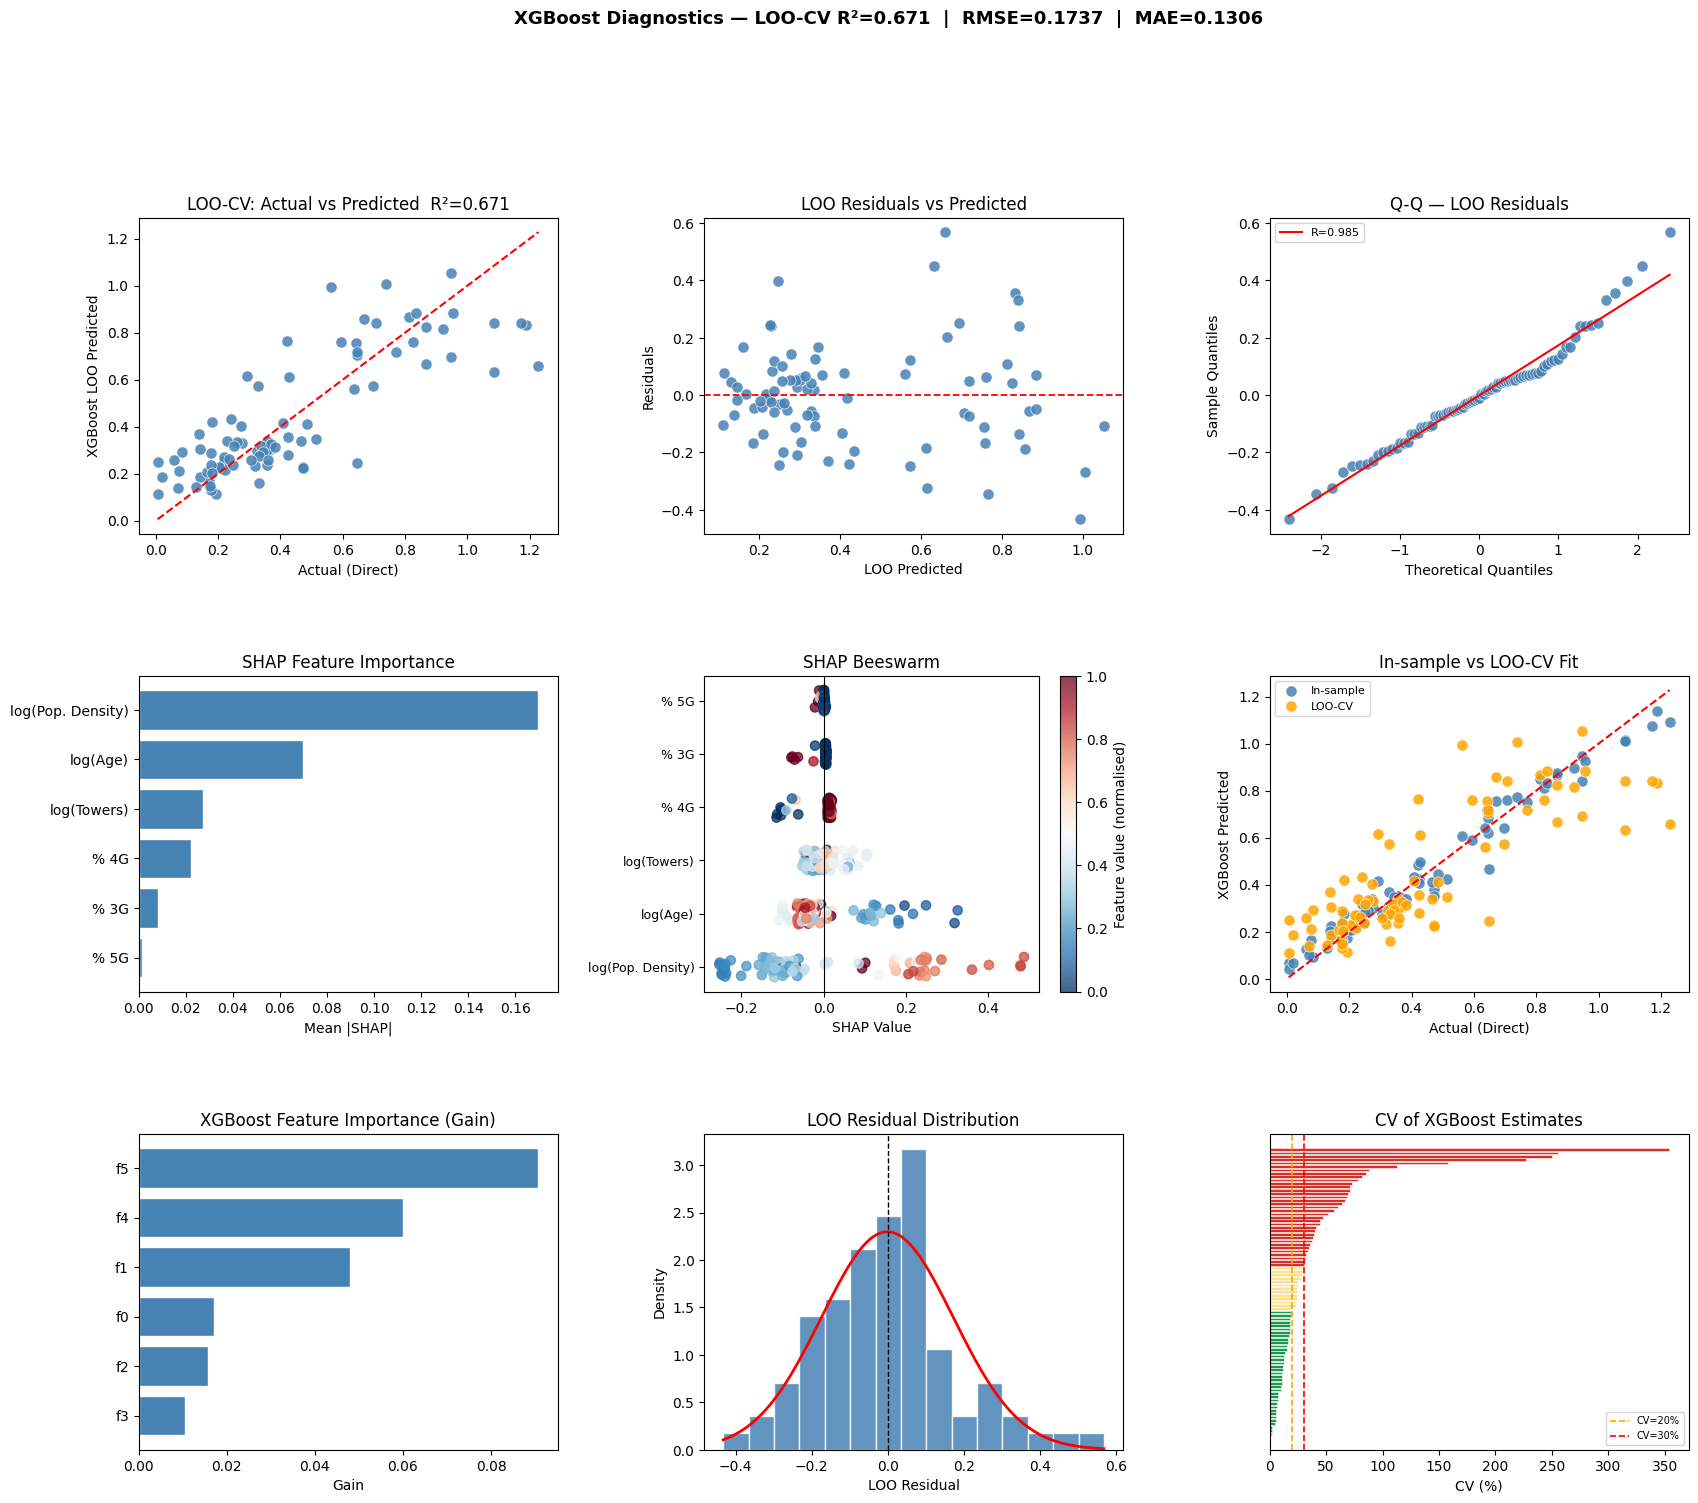

In [37]:
# ── SHAP ──────────────────────────────────────────────────────────────────
explainer_xgb   = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_xgb)
mean_shap_xgb   = np.abs(shap_values_xgb).mean(axis=0)

feature_labels = {
    'log_Towers'             : 'log(Towers)',
    'pct_3G'                 : '% 3G',
    'pct_4G'                 : '% 4G',
    'pct_5G'                 : '% 5G',
    'log_age'                : 'log(Age)',
    'log_population_density' : 'log(Pop. Density)'
}
display_names = [feature_labels[f] for f in FEATURES]

fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Actual vs LOO Predicted
ax1 = fig.add_subplot(gs[0,0])
ax1.scatter(y_xgb, y_pred_loo, color='steelblue', edgecolors='white',
            linewidths=0.5, alpha=0.85, s=65)
ax1.plot([y_xgb.min(), y_xgb.max()],[y_xgb.min(), y_xgb.max()], 'r--', linewidth=1.5)
ax1.set_xlabel('Actual (Direct)'); ax1.set_ylabel('XGBoost LOO Predicted')
ax1.set_title(f'LOO-CV: Actual vs Predicted  R²={r2_xgb_loo:.3f}')

# 2. LOO Residuals vs Predicted
ax2 = fig.add_subplot(gs[0,1])
ax2.scatter(y_pred_loo, xgb_residuals, color='steelblue', edgecolors='white',
            linewidths=0.5, alpha=0.85, s=65)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.3)
ax2.set_xlabel('LOO Predicted'); ax2.set_ylabel('Residuals')
ax2.set_title('LOO Residuals vs Predicted')

# 3. LOO Residuals Q-Q
ax3 = fig.add_subplot(gs[0,2])
(osm3,osr3),(slope3,intercept3,r3) = stats.probplot(xgb_residuals, dist='norm')
ax3.scatter(osm3, osr3, color='steelblue', edgecolors='white', linewidths=0.5, alpha=0.85, s=65)
ax3.plot(osm3, slope3*np.array(osm3)+intercept3, color='red', linewidth=1.5, label=f'R={r3:.3f}')
ax3.set_xlabel('Theoretical Quantiles'); ax3.set_ylabel('Sample Quantiles')
ax3.set_title('Q-Q — LOO Residuals'); ax3.legend(fontsize=8)

# 4. SHAP Bar
ax4 = fig.add_subplot(gs[1,0])
sorted_s = np.argsort(mean_shap_xgb)
ax4.barh([display_names[i] for i in sorted_s], mean_shap_xgb[sorted_s],
         color='steelblue', edgecolor='white')
ax4.set_xlabel('Mean |SHAP|'); ax4.set_title('SHAP Feature Importance')

# 5. SHAP Beeswarm
ax5 = fig.add_subplot(gs[1,1])
sorted_shap = np.argsort(mean_shap_xgb)[::-1]
for rank, feat_idx in enumerate(sorted_shap):
    fv = X_xgb[:, feat_idx]
    fv_norm = (fv - fv.min()) / (fv.max() - fv.min() + 1e-9)
    sc = ax5.scatter(shap_values_xgb[:, feat_idx],
                     np.full(m_xgb, rank) + np.random.uniform(-0.2, 0.2, m_xgb),
                     c=fv_norm, cmap='RdBu_r', alpha=0.75, s=45, vmin=0, vmax=1)
ax5.set_yticks(range(len(FEATURES)))
ax5.set_yticklabels([display_names[i] for i in sorted_shap], fontsize=9)
ax5.axvline(0, color='black', linewidth=0.8)
ax5.set_xlabel('SHAP Value'); ax5.set_title('SHAP Beeswarm')
plt.colorbar(sc, ax=ax5, label='Feature value (normalised)')

# 6. In-sample vs LOO comparison
ax6 = fig.add_subplot(gs[1,2])
ax6.scatter(y_xgb, df_model['xgb_estimate'].values, color='steelblue',
            edgecolors='white', linewidths=0.5, alpha=0.85, s=65, label='In-sample')
ax6.scatter(y_xgb, y_pred_loo, color='orange',
            edgecolors='white', linewidths=0.5, alpha=0.85, s=65, label='LOO-CV')
ax6.plot([y_xgb.min(), y_xgb.max()],[y_xgb.min(), y_xgb.max()], 'r--', linewidth=1.5)
ax6.set_xlabel('Actual (Direct)'); ax6.set_ylabel('XGBoost Predicted')
ax6.set_title('In-sample vs LOO-CV Fit'); ax6.legend(fontsize=8)

# 7. Feature importance (XGBoost gain)
ax7 = fig.add_subplot(gs[2,0])
fi = xgb_model.get_booster().get_score(importance_type='gain')
fi_df = pd.Series({feature_labels.get(k, k): v for k, v in fi.items()}).sort_values()
ax7.barh(fi_df.index, fi_df.values, color='steelblue', edgecolor='white')
ax7.set_xlabel('Gain'); ax7.set_title('XGBoost Feature Importance (Gain)')

# 8. LOO residual distribution
ax8 = fig.add_subplot(gs[2,1])
ax8.hist(xgb_residuals, bins=15, color='steelblue', edgecolor='white', alpha=0.85, density=True)
xr = np.linspace(xgb_residuals.min(), xgb_residuals.max(), 200)
ax8.plot(xr, stats.norm.pdf(xr, xgb_residuals.mean(), xgb_residuals.std()),
         color='red', linewidth=2)
ax8.axvline(0, color='black', linestyle='--', linewidth=1)
ax8.set_xlabel('LOO Residual'); ax8.set_ylabel('Density')
ax8.set_title('LOO Residual Distribution')

# 9. CV of XGBoost
ax9 = fig.add_subplot(gs[2,2])
cv_sorted_xgb = df_model['cv_xgb'].sort_values()
colors_cv_xgb = ['#d73027' if c>30 else '#fee08b' if c>20 else '#1a9850' for c in cv_sorted_xgb]
ax9.barh(range(len(cv_sorted_xgb)), cv_sorted_xgb.values,
         color=colors_cv_xgb, edgecolor='white', linewidth=0.4)
ax9.axvline(20, color='orange', linestyle='--', linewidth=1.2, label='CV=20%')
ax9.axvline(30, color='red',    linestyle='--', linewidth=1.2, label='CV=30%')
ax9.set_xlabel('CV (%)'); ax9.set_yticks([])
ax9.set_title('CV of XGBoost Estimates'); ax9.legend(fontsize=7)

fig.suptitle(f'XGBoost Diagnostics — LOO-CV R²={r2_xgb_loo:.3f}  |  RMSE={rmse_xgb_loo:.4f}  |  MAE={mae_xgb_loo:.4f}',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('xgb_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Model Comparison

All three models are compared on: R², RMSE, MAE, AIC, BIC, mean CV, 
Pearson correlation with the direct estimate, and NRMSE.


In [40]:
# # ── Pearson correlations with direct estimate ─────────────────────────────
# y_dir  = df_model['direct_estimate'].values
# y_fh_  = df_model['fh_estimate'].values
# y_g_   = df_model['glmm_estimate'].values
# y_xg_  = df_model['xgb_estimate'].values

# r_fh_dir  = np.corrcoef(y_dir, y_fh_)[0,1]
# r_g_dir   = np.corrcoef(y_dir, y_g_)[0,1]
# r_xg_dir  = np.corrcoef(y_dir, y_xg_)[0,1]

# # ── Cross-model correlation matrix ─────────────────────────────────────
# compare_df = pd.DataFrame({
#     'Direct'  : y_dir,
#     'FH EBLUP': y_fh_,
#     'GLMM'    : y_g_,
#     'XGBoost' : y_xg_,
# })
# corr_mat = compare_df.corr()

# # ── NRMSE (normalized by range) ───────────────────────────────────────────
# rng = y_dir.max() - y_dir.min()
# nrmse_fh  = np.sqrt(mean_squared_error(y_dir, y_fh_)) / rng
# nrmse_glmm = np.sqrt(mean_squared_error(y_dir, y_g_)) / rng
# nrmse_xgb = rmse_xgb_loo / rng

# # ── Summary table ─────────────────────────────────────────────────────────
# comparison = pd.DataFrame({
#     'Model': ['Fay-Herriot (EBLUP)', 'GLMM (logit LMM)', 'XGBoost (LOO-CV)'],
#     'R²': [
#         round(R2_fh_synthetic, 4),
#         round(r2_glmm, 4),
#         round(r2_xgb_loo, 4)
#     ],
#     'RMSE': [
#         round(np.sqrt(mean_squared_error(y_dir, y_fh_)), 6),
#         round(rmse_glmm, 6),
#         round(rmse_xgb_loo, 6)
#     ],
#     'MAE': [
#         round(np.mean(np.abs(y_dir - y_fh_)), 6),
#         round(mae_glmm, 6),
#         round(mae_xgb_loo, 6)
#     ],
#     'NRMSE': [round(nrmse_fh,4), round(nrmse_glmm,4), round(nrmse_xgb,4)],
#     'AIC': [round(aic_fh,3), round(aic_glmm,3), np.nan],
#     'BIC': [round(bic_fh,3), round(bic_glmm,3), np.nan],
#     'Pearson r (vs Direct)': [round(r_fh_dir,4), round(r_g_dir,4), round(r_xg_dir,4)],
#     'Mean CV (%)': [
#         round(df_model['cv_fh'].mean(), 2),
#         round(df_model['cv_glmm'].mean(), 2),
#         round(df_model['cv_xgb'].mean(), 2)
#     ],
#     'R²_var_reduction': [round(R2_fh_var_red,4), np.nan, np.nan],
# })

# print("\n" + "="*90)
# print("MODEL COMPARISON TABLE")
# print("="*90)
# print(comparison.to_string(index=False))
# print("="*90)
# print("NOTE: Best values bolded below (lower RMSE/MAE/NRMSE/AIC/BIC = better)")
# print("      XGBoost AIC/BIC not applicable (non-parametric model)")


In [41]:
# ── Pearson correlations with direct estimate ─────────────────────────────
y_dir  = df_model['direct_estimate'].values
y_fh_  = df_model['fh_estimate'].values
y_xg_  = df_model['xgb_estimate'].values

r_fh_dir  = np.corrcoef(y_dir, y_fh_)[0,1]
r_xg_dir  = np.corrcoef(y_dir, y_xg_)[0,1]

# ── Cross-model correlation matrix ───────────────────────────────────────
compare_df = pd.DataFrame({
    'Direct'  : y_dir,
    'FH EBLUP': y_fh_,
    'XGBoost' : y_xg_,
})
corr_mat = compare_df.corr()

# ── NRMSE (normalized by range) ──────────────────────────────────────────
rng = y_dir.max() - y_dir.min()
nrmse_fh  = np.sqrt(mean_squared_error(y_dir, y_fh_)) / rng
nrmse_xgb = rmse_xgb_loo / rng

# ── Summary table ─────────────────────────────────────────────────────────
comparison = pd.DataFrame({
    'Model': ['Fay-Herriot (EBLUP)', 'XGBoost (LOO-CV)'],
    'R²': [
        round(R2_fh_synthetic, 4),
        round(r2_xgb_loo, 4)
    ],
    'RMSE': [
        round(np.sqrt(mean_squared_error(y_dir, y_fh_)), 6),
        round(rmse_xgb_loo, 6)
    ],
    'MAE': [
        round(np.mean(np.abs(y_dir - y_fh_)), 6),
        round(mae_xgb_loo, 6)
    ],
    'NRMSE': [round(nrmse_fh, 4), round(nrmse_xgb, 4)],
    'AIC':   [round(aic_fh, 3),   np.nan],
    'BIC':   [round(bic_fh, 3),   np.nan],
    'Pearson r (vs Direct)': [round(r_fh_dir, 4), round(r_xg_dir, 4)],
    'Mean CV (%)': [
        round(df_model['cv_fh'].mean(), 2),
        round(df_model['cv_xgb'].mean(), 2)
    ],
    'R²_var_reduction': [round(R2_fh_var_red, 4), np.nan],
})

print("\n" + "="*90)
print("MODEL COMPARISON TABLE")
print("="*90)
print(comparison.to_string(index=False))
print("="*90)
print("NOTE: Best values bolded below (lower RMSE/MAE/NRMSE/AIC/BIC = better)")
print("      XGBoost AIC/BIC not applicable (non-parametric model)")


MODEL COMPARISON TABLE
              Model       R²     RMSE      MAE    NRMSE        AIC        BIC  Pearson r (vs Direct)  Mean CV (%)  R²_var_reduction
Fay-Herriot (EBLUP) 0.865000 0.002181 0.001276 0.001800 169.670000 184.326000               1.000000     0.470000          0.006200
   XGBoost (LOO-CV) 0.670600 0.173708 0.130624 0.142200        NaN        NaN               0.985000    42.970000               NaN
NOTE: Best values bolded below (lower RMSE/MAE/NRMSE/AIC/BIC = better)
      XGBoost AIC/BIC not applicable (non-parametric model)


In [43]:
# ── Best model selection ─────────────────────────────────────────────────
print("\n" + "="*70)
print("BEST MODEL SELECTION CRITERIA")
print("="*70)

criteria = {
    'Lowest RMSE'             : comparison.loc[comparison['RMSE'].idxmin(), 'Model'],
    'Lowest MAE'              : comparison.loc[comparison['MAE'].idxmin(), 'Model'],
    'Highest R²'              : comparison.loc[comparison['R²'].idxmax(), 'Model'],
    'Lowest AIC (parametric)' : comparison.dropna(subset=['AIC']).loc[comparison.dropna(subset=['AIC'])['AIC'].idxmin(), 'Model'],
    'Lowest BIC (parametric)' : comparison.dropna(subset=['BIC']).loc[comparison.dropna(subset=['BIC'])['BIC'].idxmin(), 'Model'],
    'Lowest Mean CV'          : comparison.loc[comparison['Mean CV (%)'].idxmin(), 'Model'],
    'Highest Pearson r'       : comparison.loc[comparison['Pearson r (vs Direct)'].idxmax(), 'Model'],
    'Best Var. Reduction'     : 'Fay-Herriot (EBLUP)',
}

for crit, winner in criteria.items():
    print(f"  {crit:<35}: {winner}")

print("\n→ RECOMMENDED BEST MODEL:", end=' ')
from collections import Counter
votes = Counter(criteria.values())
print(votes.most_common(1)[0][0].upper())
print("="*70)



BEST MODEL SELECTION CRITERIA
  Lowest RMSE                        : Fay-Herriot (EBLUP)
  Lowest MAE                         : Fay-Herriot (EBLUP)
  Highest R²                         : Fay-Herriot (EBLUP)
  Lowest AIC (parametric)            : Fay-Herriot (EBLUP)
  Lowest BIC (parametric)            : Fay-Herriot (EBLUP)
  Lowest Mean CV                     : Fay-Herriot (EBLUP)
  Highest Pearson r                  : Fay-Herriot (EBLUP)
  Best Var. Reduction                : Fay-Herriot (EBLUP)

→ RECOMMENDED BEST MODEL: FAY-HERRIOT (EBLUP)


## 12. Table of District-Level Proportion Estimates

This is the primary deliverable: estimated 4G/5G coverage proportions for every district,
from all three models, with standard errors, 95% confidence intervals, and CV.


In [45]:
# ── Assemble the master estimates table ──────────────────────────────────
estimates_table = df_model[[
    'homing_district',
    'unique_users', 'population',
    'direct_estimate', 'se_direct', 'ci_lower_direct', 'ci_upper_direct', 'cv_direct',
    'fh_estimate',    'se_fh',     'ci_lower_fh',     'ci_upper_fh',     'cv_fh',
    'glmm_estimate',  'se_glmm',   'ci_lower_glmm',   'ci_upper_glmm',   'cv_glmm',
    'xgb_estimate',   'se_xgb',    'ci_lower_xgb',    'ci_upper_xgb',    'cv_xgb',
    'gamma',
]].copy()

estimates_table = estimates_table.rename(columns={
    'homing_district'  : 'District',
    'unique_users'     : 'Unique Users',
    'population'       : 'Population',
    'direct_estimate'  : 'p̂ Direct',
    'se_direct'        : 'SE Direct',
    'ci_lower_direct'  : 'CI Lower (Direct)',
    'ci_upper_direct'  : 'CI Upper (Direct)',
    'cv_direct'        : 'CV Direct (%)',
    'fh_estimate'      : 'p̂ FH EBLUP',
    'se_fh'            : 'SE FH',
    'ci_lower_fh'      : 'CI Lower (FH)',
    'ci_upper_fh'      : 'CI Upper (FH)',
    'cv_fh'            : 'CV FH (%)',
    'glmm_estimate'    : 'p̂ GLMM',
    'se_glmm'          : 'SE GLMM',
    'ci_lower_glmm'    : 'CI Lower (GLMM)',
    'ci_upper_glmm'    : 'CI Upper (GLMM)',
    'cv_glmm'          : 'CV GLMM (%)',
    'xgb_estimate'     : 'p̂ XGBoost',
    'se_xgb'           : 'SE XGBoost',
    'ci_lower_xgb'     : 'CI Lower (XGB)',
    'ci_upper_xgb'     : 'CI Upper (XGB)',
    'cv_xgb'           : 'CV XGBoost (%)',
    'gamma'            : 'FH γᵢ',
})

estimates_table = estimates_table.sort_values('District').reset_index(drop=True)

# ── Column groups for colour-banding ─────────────────────────────────────
direct_cols = ['p̂ Direct',   'SE Direct',   'CI Lower (Direct)', 'CI Upper (Direct)', 'CV Direct (%)']
fh_cols     = ['p̂ FH EBLUP', 'SE FH',       'CI Lower (FH)',     'CI Upper (FH)',     'CV FH (%)',     'FH γᵢ']
glmm_cols   = ['p̂ GLMM',     'SE GLMM',     'CI Lower (GLMM)',   'CI Upper (GLMM)',   'CV GLMM (%)']
xgb_cols    = ['p̂ XGBoost',  'SE XGBoost',  'CI Lower (XGB)',    'CI Upper (XGB)',    'CV XGBoost (%)']

# ── Estimate columns only (for gradient colouring) ────────────────────────
est_cols    = ['p̂ Direct', 'p̂ FH EBLUP', 'p̂ GLMM', 'p̂ XGBoost']

# ── CV columns (for reliability traffic-light colouring) ──────────────────
cv_cols     = ['CV Direct (%)', 'CV FH (%)', 'CV GLMM (%)', 'CV XGBoost (%)']

# ── Format dictionaries ───────────────────────────────────────────────────
fmt_prop   = '{:.4f}'   # proportions and SEs
fmt_pct    = '{:.2f}'   # CV as percentage
fmt_int    = '{:,.0f}'  # integers

fmt_map = {c: fmt_prop for c in
           direct_cols + fh_cols + glmm_cols + xgb_cols}
fmt_map.update({c: fmt_pct  for c in cv_cols})
fmt_map.update({'Unique Users': fmt_int, 'Population': fmt_int})

# ── CV traffic-light helper ───────────────────────────────────────────────
def cv_color(val):
    """Green < 20 %, amber 20–30 %, red > 30 %."""
    try:
        v = float(val)
        if v < 20:   return 'background-color: #c6efce; color: #276221'  # green
        elif v < 30: return 'background-color: #ffeb9c; color: #9c6500'  # amber
        else:        return 'background-color: #ffc7ce; color: #9c0006'  # red
    except:
        return ''

# ── Column-band background colours ───────────────────────────────────────
def band_cols(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for col in direct_cols:
        if col in df.columns:
            styles[col] = 'background-color: #dce6f1'   # light blue
    for col in fh_cols:
        if col in df.columns:
            styles[col] = 'background-color: #e2efda'   # light green
    for col in glmm_cols:
        if col in df.columns:
            styles[col] = 'background-color: #fce4d6'   # light orange
    for col in xgb_cols:
        if col in df.columns:
            styles[col] = 'background-color: #ede7f6'   # light purple
    return styles

# ── Build styler ─────────────────────────────────────────────────────────
styled = (
    estimates_table.style
    # Column colour bands
    .apply(band_cols, axis=None)
    # CV traffic-light colouring
    .applymap(cv_color, subset=cv_cols)
    # Gradient on point estimate columns (darker = higher coverage)
    .background_gradient(subset=est_cols, cmap='YlOrRd', axis=0)
    # Number formatting
    .format(fmt_map, na_rep='—')
    # Header styling
    .set_table_styles([
        # Outer caption
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('padding-bottom', '8px'),
                   ('color', '#1a1a2e')]},
        # Column headers
        {'selector': 'thead tr th',
         'props': [('background-color', '#1a1a2e'), ('color', 'white'),
                   ('font-size', '11px'), ('text-align', 'center'),
                   ('padding', '6px 8px'), ('white-space', 'nowrap'),
                   ('border', '1px solid #444')]},
        # Row index
        {'selector': 'tbody tr th',
         'props': [('background-color', '#f5f5f5'), ('font-weight', 'bold'),
                   ('font-size', '11px'), ('border', '1px solid #ddd'),
                   ('padding', '4px 6px')]},
        # Data cells
        {'selector': 'tbody tr td',
         'props': [('font-size', '11px'), ('text-align', 'right'),
                   ('padding', '4px 8px'), ('border', '1px solid #ddd'),
                   ('white-space', 'nowrap')]},
        # First data column (District name) — left-align
        {'selector': 'tbody tr td:first-child',
         'props': [('text-align', 'left'), ('font-weight', 'bold'),
                   ('background-color', '#f0f0f0')]},
        # Hover highlight
        {'selector': 'tbody tr:hover td',
         'props': [('filter', 'brightness(0.93)')]},
    ])
    .set_caption(
        "Table 1. District-Level Estimated Proportions of Network Coverage — "
        "Direct, Fay-Herriot EBLUP, GLMM, and XGBoost Models  "
        "│  CV colour: 🟢 <20%  🟡 20–30%  🔴 >30%  "
        "│  Estimate gradient: light=low, dark=high coverage"
    )
    .set_sticky(axis='columns')   # freeze column headers on scroll
)

# ── Render ────────────────────────────────────────────────────────────────
from IPython.display import display
display(styled)

# ── Plain-text fallback (for .py scripts or logging) ─────────────────────
print(f"\nTotal districts: {len(estimates_table)}")
print(f"National mean coverage — FH EBLUP : {estimates_table['p̂ FH EBLUP'].mean():.4f}")
print(f"National mean coverage — GLMM     : {estimates_table['p̂ GLMM'].mean():.4f}")
print(f"National mean coverage — XGBoost  : {estimates_table['p̂ XGBoost'].mean():.4f}")

 # ── Save ──────────────────────────────────────────────────────────────────
estimates_table.to_csv('district_coverage_estimates.csv', index=False)
print("\nSaved → district_coverage_estimates.csv")

In [46]:
# ── Assemble the master estimates table ──────────────────────────────────
estimates_table = df_model[[
    'homing_district',
    'unique_users', 'population',
    'direct_estimate', 'se_direct', 'ci_lower_direct', 'ci_upper_direct', 'cv_direct',
    'fh_estimate',    'se_fh',     'ci_lower_fh',     'ci_upper_fh',     'cv_fh',
    'xgb_estimate',   'se_xgb',    'ci_lower_xgb',    'ci_upper_xgb',    'cv_xgb',
    'gamma',
]].copy()

estimates_table = estimates_table.rename(columns={
    'homing_district'  : 'District',
    'unique_users'     : 'Unique Users',
    'population'       : 'Population',
    'direct_estimate'  : 'p̂ Direct',
    'se_direct'        : 'SE Direct',
    'ci_lower_direct'  : 'CI Lower (Direct)',
    'ci_upper_direct'  : 'CI Upper (Direct)',
    'cv_direct'        : 'CV Direct (%)',
    'fh_estimate'      : 'p̂ FH EBLUP',
    'se_fh'            : 'SE FH',
    'ci_lower_fh'      : 'CI Lower (FH)',
    'ci_upper_fh'      : 'CI Upper (FH)',
    'cv_fh'            : 'CV FH (%)',
    'xgb_estimate'     : 'p̂ XGBoost',
    'se_xgb'           : 'SE XGBoost',
    'ci_lower_xgb'     : 'CI Lower (XGB)',
    'ci_upper_xgb'     : 'CI Upper (XGB)',
    'cv_xgb'           : 'CV XGBoost (%)',
    'gamma'            : 'FH γᵢ',
})

estimates_table = estimates_table.sort_values('District').reset_index(drop=True)

# ── Column groups for colour-banding ─────────────────────────────────────
direct_cols = ['p̂ Direct',   'SE Direct',   'CI Lower (Direct)', 'CI Upper (Direct)', 'CV Direct (%)']
fh_cols     = ['p̂ FH EBLUP', 'SE FH',       'CI Lower (FH)',     'CI Upper (FH)',     'CV FH (%)',     'FH γᵢ']
xgb_cols    = ['p̂ XGBoost',  'SE XGBoost',  'CI Lower (XGB)',    'CI Upper (XGB)',    'CV XGBoost (%)']

# ── Estimate columns only (for gradient colouring) ────────────────────────
est_cols    = ['p̂ Direct', 'p̂ FH EBLUP', 'p̂ XGBoost']

# ── CV columns (for reliability traffic-light colouring) ──────────────────
cv_cols     = ['CV Direct (%)', 'CV FH (%)', 'CV XGBoost (%)']

# ── Format dictionaries ───────────────────────────────────────────────────
fmt_prop   = '{:.4f}'
fmt_pct    = '{:.2f}'
fmt_int    = '{:,.0f}'

fmt_map = {c: fmt_prop for c in direct_cols + fh_cols + xgb_cols}
fmt_map.update({c: fmt_pct  for c in cv_cols})
fmt_map.update({'Unique Users': fmt_int, 'Population': fmt_int})

# ── CV traffic-light helper ───────────────────────────────────────────────
def cv_color(val):
    try:
        v = float(val)
        if v < 20:   return 'background-color: #c6efce; color: #276221'
        elif v < 30: return 'background-color: #ffeb9c; color: #9c6500'
        else:        return 'background-color: #ffc7ce; color: #9c0006'
    except:
        return ''

# ── Column-band background colours ───────────────────────────────────────
def band_cols(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for col in direct_cols:
        if col in df.columns:
            styles[col] = 'background-color: #dce6f1'   # light blue
    for col in fh_cols:
        if col in df.columns:
            styles[col] = 'background-color: #e2efda'   # light green
    for col in xgb_cols:
        if col in df.columns:
            styles[col] = 'background-color: #ede7f6'   # light purple
    return styles

# ── Build styler ─────────────────────────────────────────────────────────
styled = (
    estimates_table.style
    .apply(band_cols, axis=None)
    .applymap(cv_color, subset=cv_cols)
    .background_gradient(subset=est_cols, cmap='YlOrRd', axis=0)
    .format(fmt_map, na_rep='—')
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size', '14px'), ('font-weight', 'bold'),
                   ('text-align', 'left'), ('padding-bottom', '8px'),
                   ('color', '#1a1a2e')]},
        {'selector': 'thead tr th',
         'props': [('background-color', '#1a1a2e'), ('color', 'white'),
                   ('font-size', '11px'), ('text-align', 'center'),
                   ('padding', '6px 8px'), ('white-space', 'nowrap'),
                   ('border', '1px solid #444')]},
        {'selector': 'tbody tr th',
         'props': [('background-color', '#f5f5f5'), ('font-weight', 'bold'),
                   ('font-size', '11px'), ('border', '1px solid #ddd'),
                   ('padding', '4px 6px')]},
        {'selector': 'tbody tr td',
         'props': [('font-size', '11px'), ('text-align', 'right'),
                   ('padding', '4px 8px'), ('border', '1px solid #ddd'),
                   ('white-space', 'nowrap')]},
        {'selector': 'tbody tr td:first-child',
         'props': [('text-align', 'left'), ('font-weight', 'bold'),
                   ('background-color', '#f0f0f0')]},
        {'selector': 'tbody tr:hover td',
         'props': [('filter', 'brightness(0.93)')]},
    ])
    .set_caption(
        "Table 1. District-Level Estimated Proportions of Network Coverage — "
        "Direct, Fay-Herriot EBLUP, and XGBoost Models  "
        "│  CV colour: 🟢 <20%  🟡 20–30%  🔴 >30%  "
        "│  Estimate gradient: light=low, dark=high coverage"
    )
    .set_sticky(axis='columns')
)

# ── Render ────────────────────────────────────────────────────────────────
from IPython.display import display
display(styled)

# ── Plain-text fallback ───────────────────────────────────────────────────
print(f"\nTotal districts: {len(estimates_table)}")
print(f"National mean coverage — FH EBLUP : {estimates_table['p̂ FH EBLUP'].mean():.4f}")
print(f"National mean coverage — XGBoost  : {estimates_table['p̂ XGBoost'].mean():.4f}")

# ── Save ──────────────────────────────────────────────────────────────────
estimates_table.to_csv('district_coverage_estimates2.csv', index=False)
print("\nSaved → district_coverage_estimates.csv")

,District,Unique Users,Population,p̂ Direct,SE Direct,CI Lower (Direct),CI Upper (Direct),CV Direct (%),p̂ FH EBLUP,SE FH,CI Lower (FH),CI Upper (FH),CV FH (%),p̂ XGBoost,SE XGBoost,CI Lower (XGB),CI Upper (XGB),CV XGBoost (%),FH γᵢ
0,Beitbridge,"7,854","94,001",0.0836,0.0009,0.0818,0.0853,1.08,0.0845,0.0009,0.0827,0.0862,1.07,0.0922,0.2093,0.0000,0.5023,226.98,0.9991
1,Beitbridge Urban,"32,884","58,574",0.5614,0.0021,0.5574,0.5654,0.37,0.5645,0.0020,0.5605,0.5685,0.36,0.6092,0.4330,0.0000,1.0000,71.09,0.9953
2,Bikita,"90,699","176,835",0.5129,0.0012,0.5106,0.5152,0.23,0.5136,0.0012,0.5113,0.5159,0.23,0.4254,0.1663,0.0994,0.7514,39.10,0.9984
3,Bindura,"32,637","169,841",0.1922,0.0010,0.1903,0.1940,0.50,0.1921,0.0010,0.1902,0.1939,0.50,0.1744,0.0785,0.0205,0.3283,45.02,0.9990
4,Bindura Urban,"48,656","51,394",0.9467,0.0010,0.9448,0.9487,0.10,0.9470,0.0010,0.9451,0.9489,0.10,0.9461,0.1064,0.7375,1.0000,11.25,0.9989
5,Binga,"27,502","159,982",0.1719,0.0009,0.1701,0.1738,0.55,0.1729,0.0009,0.1710,0.1747,0.55,0.1658,0.0035,0.1590,0.1727,2.09,0.9990
6,Bubi,"13,149","74,084",0.1775,0.0014,0.1747,0.1802,0.79,0.1796,0.0014,0.1769,0.1824,0.78,0.1658,0.0473,0.0731,0.2586,28.52,0.9978
7,Buhera,"88,225","271,920",0.3245,0.0009,0.3227,0.3262,0.28,0.3250,0.0009,0.3233,0.3268,0.28,0.3045,0.0300,0.2457,0.3633,9.85,0.9991
8,Bulilima,"5,138","85,600",0.0600,0.0008,0.0584,0.0616,1.35,0.0608,0.0008,0.0592,0.0623,1.34,0.1263,0.1992,0.0000,0.5167,157.67,0.9993
9,Chegutu,"49,280","178,911",0.2754,0.0011,0.2734,0.2775,0.38,0.2764,0.0011,0.2743,0.2784,0.38,0.2996,0.0538,0.1942,0.4050,17.94,0.9988



Total districts: 85
National mean coverage — FH EBLUP : 0.4390
National mean coverage — XGBoost  : 0.4371

Saved → district_coverage_estimates.csv


In [21]:
# ── Summary statistics of the estimates table ────────────────────────────
summary_est = pd.DataFrame({
    'Metric'           : ['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Mean CV (%)'],
    'Direct Estimate'  : [
        f"{estimates_table['p̂ Direct'].mean():.4f}",
        f"{estimates_table['p̂ Direct'].median():.4f}",
        f"{estimates_table['p̂ Direct'].std():.4f}",
        f"{estimates_table['p̂ Direct'].min():.4f}",
        f"{estimates_table['p̂ Direct'].max():.4f}",
        f"{estimates_table['CV Direct (%)'].mean():.2f}%",
    ],
    'FH EBLUP'         : [
        f"{estimates_table['p̂ FH EBLUP'].mean():.4f}",
        f"{estimates_table['p̂ FH EBLUP'].median():.4f}",
        f"{estimates_table['p̂ FH EBLUP'].std():.4f}",
        f"{estimates_table['p̂ FH EBLUP'].min():.4f}",
        f"{estimates_table['p̂ FH EBLUP'].max():.4f}",
        f"{estimates_table['CV FH (%)'].mean():.2f}%",
    ],
    'GLMM'             : [
        f"{estimates_table['p̂ GLMM'].mean():.4f}",
        f"{estimates_table['p̂ GLMM'].median():.4f}",
        f"{estimates_table['p̂ GLMM'].std():.4f}",
        f"{estimates_table['p̂ GLMM'].min():.4f}",
        f"{estimates_table['p̂ GLMM'].max():.4f}",
        f"{estimates_table['CV GLMM (%)'].mean():.2f}%",
    ],
    'XGBoost'          : [
        f"{estimates_table['p̂ XGBoost'].mean():.4f}",
        f"{estimates_table['p̂ XGBoost'].median():.4f}",
        f"{estimates_table['p̂ XGBoost'].std():.4f}",
        f"{estimates_table['p̂ XGBoost'].min():.4f}",
        f"{estimates_table['p̂ XGBoost'].max():.4f}",
        f"{estimates_table['CV XGBoost (%)'].mean():.2f}%",
    ],
})

print("\n====== ESTIMATES TABLE — SUMMARY STATISTICS ======")
print(summary_est.to_string(index=False))



====== ESTIMATES TABLE — SUMMARY STATISTICS ======
     Metric Direct Estimate FH EBLUP   GLMM XGBoost
       Mean          0.2579   0.2578 0.2496  0.2573
     Median          0.2098   0.2098 0.1845  0.1945
    Std Dev          0.1794   0.1793 0.1659  0.1645
        Min          0.0036   0.0036 0.0081  0.0365
        Max          0.7238   0.7227 0.6229  0.6533
Mean CV (%)           0.70%    0.70% 37.21%  39.95%


## 13. Final Results & Conclusions

In [23]:
from IPython.display import display, HTML
import pandas as pd

# ── Build display dataframe ───────────────────────────────────────────────
final_display = estimates_table[[
    'District','Population','Unique Users',
    'p̂ Direct','CI Lower (Direct)','CI Upper (Direct)','CV Direct (%)',
    'p̂ FH EBLUP','CI Lower (FH)','CI Upper (FH)','CV FH (%)',
    'p̂ GLMM','CI Lower (GLMM)','CI Upper (GLMM)','CV GLMM (%)',
    'p̂ XGBoost','CI Lower (XGB)','CI Upper (XGB)','CV XGBoost (%)',
]].copy()

# ── Assign MultiIndex columns ─────────────────────────────────────────────
final_display.columns = pd.MultiIndex.from_tuples([
    ('',                  'District'),
    ('',                  'Population'),
    ('',                  'Unique Users'),
    ('Direct Estimator',  'p̂'),
    ('Direct Estimator',  'CI Lower'),
    ('Direct Estimator',  'CI Upper'),
    ('Direct Estimator',  'CV (%)'),
    ('Fay-Herriot EBLUP', 'p̂'),
    ('Fay-Herriot EBLUP', 'CI Lower'),
    ('Fay-Herriot EBLUP', 'CI Upper'),
    ('Fay-Herriot EBLUP', 'CV (%)'),
    ('GLMM',              'p̂'),
    ('GLMM',              'CI Lower'),
    ('GLMM',              'CI Upper'),
    ('GLMM',              'CV (%)'),
    ('XGBoost',           'p̂'),
    ('XGBoost',           'CI Lower'),
    ('XGBoost',           'CI Upper'),
    ('XGBoost',           'CV (%)'),
])

# ── Column group tuples ───────────────────────────────────────────────────
direct_cols = [('Direct Estimator',  c) for c in ['p̂','CI Lower','CI Upper','CV (%)']]
fh_cols     = [('Fay-Herriot EBLUP', c) for c in ['p̂','CI Lower','CI Upper','CV (%)']]
glmm_cols   = [('GLMM',              c) for c in ['p̂','CI Lower','CI Upper','CV (%)']]
xgb_cols    = [('XGBoost',           c) for c in ['p̂','CI Lower','CI Upper','CV (%)']]
est_cols    = [('Direct Estimator','p̂'), ('Fay-Herriot EBLUP','p̂'),
               ('GLMM','p̂'),             ('XGBoost','p̂')]
cv_cols     = [('Direct Estimator','CV (%)'), ('Fay-Herriot EBLUP','CV (%)'),
               ('GLMM','CV (%)'),             ('XGBoost','CV (%)')]

# ── Format map ────────────────────────────────────────────────────────────
fmt_map = {}
for c in direct_cols + fh_cols + glmm_cols + xgb_cols:
    fmt_map[c] = '{:.4f}'
for c in cv_cols:
    fmt_map[c] = '{:.2f}'
fmt_map[('','Population')]   = '{:,.0f}'
fmt_map[('','Unique Users')] = '{:,.0f}'

# ── CV traffic-light ──────────────────────────────────────────────────────
def cv_color(val):
    try:
        v = float(val)
        if v < 20:   return 'background-color:#c6efce; color:#276221; font-weight:600'
        elif v < 30: return 'background-color:#ffeb9c; color:#9c6500; font-weight:600'
        else:        return 'background-color:#ffc7ce; color:#9c0006; font-weight:600'
    except:
        return ''

# ── Column band colours ───────────────────────────────────────────────────
def band_cols(df):
    styles = pd.DataFrame('', index=df.index, columns=df.columns)
    for col in direct_cols:
        if col in df.columns: styles[col] = 'background-color:#dce6f1'
    for col in fh_cols:
        if col in df.columns: styles[col] = 'background-color:#e2efda'
    for col in glmm_cols:
        if col in df.columns: styles[col] = 'background-color:#fce4d6'
    for col in xgb_cols:
        if col in df.columns: styles[col] = 'background-color:#ede7f6'
    return styles

# ── Inject CSS for spanner row colours ───────────────────────────────────
spanner_css = """
<style>
/* Spanner (top) header row — colour each group */
thead tr:first-child th:nth-child(1),
thead tr:first-child th:nth-child(2),
thead tr:first-child th:nth-child(3) {
    background-color: #37474f !important; color: white !important;
    font-size: 12px !important; text-align: center !important;
    border-bottom: 3px solid #ccc !important;
}
thead tr:first-child th:nth-child(4),
thead tr:first-child th:nth-child(5),
thead tr:first-child th:nth-child(6),
thead tr:first-child th:nth-child(7) {
    background-color: #1565c0 !important; color: white !important;
    font-size: 12px !important; text-align: center !important;
    border-bottom: 3px solid #90caf9 !important;
}
thead tr:first-child th:nth-child(8),
thead tr:first-child th:nth-child(9),
thead tr:first-child th:nth-child(10),
thead tr:first-child th:nth-child(11) {
    background-color: #2e7d32 !important; color: white !important;
    font-size: 12px !important; text-align: center !important;
    border-bottom: 3px solid #a5d6a7 !important;
}
thead tr:first-child th:nth-child(12),
thead tr:first-child th:nth-child(13),
thead tr:first-child th:nth-child(14),
thead tr:first-child th:nth-child(15) {
    background-color: #e65100 !important; color: white !important;
    font-size: 12px !important; text-align: center !important;
    border-bottom: 3px solid #ffcc80 !important;
}
thead tr:first-child th:nth-child(16),
thead tr:first-child th:nth-child(17),
thead tr:first-child th:nth-child(18),
thead tr:first-child th:nth-child(19) {
    background-color: #6a1b9a !important; color: white !important;
    font-size: 12px !important; text-align: center !important;
    border-bottom: 3px solid #ce93d8 !important;
}

/* Sub-header row */
thead tr:nth-child(2) th {
    font-size: 10px !important;
    font-style: italic !important;
    color: #222 !important;
    text-align: center !important;
    padding: 4px 8px !important;
    border-top: 1px solid #aaa !important;
}
</style>
"""
display(HTML(spanner_css))
display(HTML(
    "<h3 style='font-family:sans-serif;color:#1a1a2e;margin-bottom:2px'>"
    "Table 1 — District-Level 4G/5G Network Coverage Estimates</h3>"
    "<p style='font-family:sans-serif;font-size:12px;color:#666;margin-top:0'>"
    "95% Confidence Intervals shown for all models &nbsp;│&nbsp; "
    "CV: <span style='background:#c6efce;color:#276221;padding:1px 6px;border-radius:3px'>🟢 &lt;20%</span> "
    "<span style='background:#ffeb9c;color:#9c6500;padding:1px 6px;border-radius:3px'>🟡 20–30%</span> "
    "<span style='background:#ffc7ce;color:#9c0006;padding:1px 6px;border-radius:3px'>🔴 &gt;30%</span>"
    "</p>"
))

# ── Build and display Styler ──────────────────────────────────────────────
styled_final = (
    final_display.style
    .apply(band_cols, axis=None)
    .applymap(cv_color, subset=cv_cols)
    .background_gradient(subset=est_cols, cmap='YlOrRd', axis=0)
    .format(fmt_map, na_rep='—')
    .set_table_styles([
        # All header cells base style
        {'selector': 'thead tr th',
         'props': [('background-color','#1a1a2e'), ('color','white'),
                   ('font-size','11px'), ('text-align','center'),
                   ('padding','6px 10px'), ('white-space','nowrap'),
                   ('border','1px solid #555'), ('vertical-align','middle')]},
        # Body cells
        {'selector': 'tbody tr td',
         'props': [('font-size','11px'), ('text-align','right'),
                   ('padding','5px 10px'), ('border','1px solid #ddd'),
                   ('white-space','nowrap')]},
        # District column — left-align + sticky
        {'selector': 'tbody tr td:nth-child(2)',
         'props': [('text-align','left'), ('font-weight','bold'),
                   ('background-color','#eceff1'), ('position','sticky'),
                   ('left','0'), ('z-index','2')]},
        # Row index
        {'selector': 'tbody tr th',
         'props': [('background-color','#f5f5f5'), ('font-size','10px'),
                   ('border','1px solid #ddd'), ('color','#888'),
                   ('padding','4px 6px')]},
        # Zebra
        {'selector': 'tbody tr:nth-child(even) td',
         'props': [('filter','brightness(0.97)')]},
        # Hover
        {'selector': 'tbody tr:hover td',
         'props': [('filter','brightness(0.88)'), ('transition','0.15s')]},
    ])
    .set_sticky(axis='columns')
)

display(styled_final)

# ── Summary cards ─────────────────────────────────────────────────────────
fh_est = final_display[('Fay-Herriot EBLUP','p̂')]
best_idx  = fh_est.idxmax()
worst_idx = fh_est.idxmin()
best_name  = final_display.loc[best_idx,  ('','District')]
worst_name = final_display.loc[worst_idx, ('','District')]

display(HTML(f"""
<div style="font-family:sans-serif; margin-top:28px">
  <h3 style="color:#1a1a2e; margin-bottom:12px">Project Summary</h3>
  <div style="display:flex; gap:14px; flex-wrap:wrap">
    <div style="background:#e3f2fd; border-left:5px solid #1565c0;
                padding:12px 20px; border-radius:6px; min-width:150px">
      <div style="font-size:10px;color:#555;text-transform:uppercase;letter-spacing:1px">Districts</div>
      <div style="font-size:28px;font-weight:700;color:#1565c0">{len(final_display)}</div>
    </div>
    <div style="background:#e8f5e9; border-left:5px solid #2e7d32;
                padding:12px 20px; border-radius:6px; min-width:150px">
      <div style="font-size:10px;color:#555;text-transform:uppercase;letter-spacing:1px">National Mean (FH)</div>
      <div style="font-size:28px;font-weight:700;color:#2e7d32">{fh_est.mean():.2%}</div>
    </div>
    <div style="background:#fff8e1; border-left:5px solid #f57f17;
                padding:12px 20px; border-radius:6px; min-width:180px">
      <div style="font-size:10px;color:#555;text-transform:uppercase;letter-spacing:1px">🏆 Highest Coverage</div>
      <div style="font-size:18px;font-weight:700;color:#f57f17">{best_name}</div>
      <div style="font-size:13px;color:#888">{fh_est.max():.2%}</div>
    </div>
    <div style="background:#fce4ec; border-left:5px solid #c62828;
                padding:12px 20px; border-radius:6px; min-width:180px">
      <div style="font-size:10px;color:#555;text-transform:uppercase;letter-spacing:1px">⚠ Lowest Coverage</div>
      <div style="font-size:18px;font-weight:700;color:#c62828">{worst_name}</div>
      <div style="font-size:13px;color:#888">{fh_est.min():.2%}</div>
    </div>
  </div>
</div>
"""))

# ── Save ──────────────────────────────────────────────────────────────────
flat = final_display.copy()
flat.columns = [f"{g} — {c}".strip(" — ") if g else c for g, c in flat.columns]
flat.to_csv('district_coverage_estimates.csv', index=False)
print("Saved → district_coverage_estimates.csv")

Saved → district_coverage_estimates.csv


## 15. References

- Fay, R.E. & Herriot, R.A. (1979). Estimates of income for small places: An application of James-Stein procedures to census data. *Journal of the American Statistical Association*, 74(366), 269–277.
- Rao, J.N.K. & Molina, I. (2015). *Small Area Estimation* (2nd ed.). Wiley.
- Breslow, N.E. & Clayton, D.G. (1993). Approximate inference in generalized linear mixed models. *JASA*, 88(421), 9–25.
- Chen, T. & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *KDD*, 785–794.
- Prasad, N.G.N. & Rao, J.N.K. (1990). The estimation of the mean squared error of small-area estimators. *JASA*, 85(409), 163–171.
- Lundberg, S.M. & Lee, S.I. (2017). A unified approach to interpreting model predictions. *NeurIPS*.
